# Hotel Booking Classification Dataset

##### This dataset contains hotel booking information, detailing successful stays and cancellations across two types of hotels: a resort hotel and a city hotel. The data includes detailed booking attributes such as arrival dates, length of stay, guest demographics, and booking specifications. Features that effect whether bookings were canceled (is_canceled=1) or resulted successful (is_canceled=0), along with customer preferences like meal plans, room types, and special requests. The dataset also average daily rates (ADR), distribution channels, and market segments

In [4]:
import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

try:
    import missingno as msno
except Exception:
    msno = None

import scipy.stats as stats
import statsmodels.api as sm

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder,
    LabelEncoder,
    OrdinalEncoder,
    PowerTransformer
)

from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    mutual_info_classif,
    f_classif,
    RFE
)
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve,
    validation_curve
)
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

try:
    import xgboost as xgb
    from xgboost import XGBClassifier
except Exception:
    xgb = None
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None

try:
    from imblearn.over_sampling import SMOTE
except Exception:
    SMOTE = None

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 0xBEEF

In [5]:
path = 'hotel_booking.csv'
hotel_dataset = pd.read_csv(path)

hotel_dataset.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [6]:
hotel_dataset.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [7]:
"""
Adding artificial nulls for the sake of the project
"""
rng = np.random.default_rng(RANDOM_STATE)
n_rows = hotel_dataset.shape[0]

n_rows_to_modify = int(0.30 * n_rows)
cols_to_modify = [c for c in hotel_dataset.columns if c != "is_canceled"]

added_counts = {col: 0 for col in cols_to_modify}

rows_to_modify = rng.choice(n_rows, size=n_rows_to_modify, replace=False)

for row_idx in rows_to_modify:
    n_cols = rng.integers(1, min(6, len(cols_to_modify) + 1))
    cols_for_row = rng.choice(cols_to_modify, size=n_cols, replace=False)

    for col in cols_for_row:
        if hotel_dataset.loc[row_idx, col] is not np.nan:
            hotel_dataset.loc[row_idx, col] = np.nan
            added_counts[col] += 1

total_added = sum(added_counts.values())
print(f"Artificial nulls added (total): {total_added}")
print(f"Rows modified: {n_rows_to_modify}")
for col, cnt in added_counts.items():
    if cnt > 0:
        print(f"  {col}: +{cnt} nulls")

Artificial nulls added (total): 107504
Rows modified: 35817
  hotel: +3075 nulls
  lead_time: +3088 nulls
  arrival_date_year: +3109 nulls
  arrival_date_month: +3109 nulls
  arrival_date_week_number: +3120 nulls
  arrival_date_day_of_month: +3071 nulls
  stays_in_weekend_nights: +3190 nulls
  stays_in_week_nights: +3040 nulls
  adults: +3030 nulls
  children: +3070 nulls
  babies: +3010 nulls
  meal: +3065 nulls
  country: +3032 nulls
  market_segment: +3090 nulls
  distribution_channel: +3099 nulls
  is_repeated_guest: +2963 nulls
  previous_cancellations: +2992 nulls
  previous_bookings_not_canceled: +3047 nulls
  reserved_room_type: +3024 nulls
  assigned_room_type: +3065 nulls
  booking_changes: +3053 nulls
  deposit_type: +3106 nulls
  agent: +3008 nulls
  company: +3098 nulls
  days_in_waiting_list: +3066 nulls
  customer_type: +2977 nulls
  adr: +3114 nulls
  required_car_parking_spaces: +3100 nulls
  total_of_special_requests: +3076 nulls
  reservation_status: +3202 nulls
  re

In [8]:
hotel_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           116315 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       116302 non-null  float64
 3   arrival_date_year               116281 non-null  float64
 4   arrival_date_month              116281 non-null  object 
 5   arrival_date_week_number        116270 non-null  float64
 6   arrival_date_day_of_month       116319 non-null  float64
 7   stays_in_weekend_nights         116200 non-null  float64
 8   stays_in_week_nights            116350 non-null  float64
 9   adults                          116360 non-null  float64
 10  children                        116316 non-null  float64
 11  babies                          116380 non-null  float64
 12  meal            

In [9]:
hotel_dataset.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,116302.000000,116281.000000,116270.000000,116319.000000,116200.000000,116350.00000,116360.000000,116316.000000,116380.000000,116427.000000,116398.000000,116343.000000,116337.000000,100450.0000,6613.000000,116324.000000,116276.000000,116290.000000,116314.000000
mean,0.370416,104.092432,2016.156707,27.151105,15.805999,0.927263,2.50110,1.856480,0.103950,0.007948,0.031977,0.087106,0.137585,0.221004,86.6378,189.386360,2.340059,101.840698,0.062533,0.571582
std,0.482918,106.901310,0.707718,13.604649,8.781162,0.997304,1.91064,0.581569,0.398662,0.097646,0.175940,0.843583,1.505654,0.652618,110.7492,131.844074,17.717590,50.580264,0.245333,0.792855
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.00000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.0000,62.000000,0.000000,69.330000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.00000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.0000,179.000000,0.000000,94.800000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.00000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.0000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.00000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.0000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [10]:
"""
Renaming columns & dropping unnecessary ones
"""
hotel_dataset.rename(columns={
    'is_canceled': 'canceled',
    'lead_time': 'lead_time_days',
    'arrival_date_year': 'arrival_year',
    'arrival_date_month': 'arrival_month',
    'arrival_date_week_number': 'arrival_week_number',
    'arrival_date_day_of_month': 'arrival_day',
    'stays_in_weekend_nights': 'stay_weekend_nights',
    'stays_in_week_nights': 'stay_week_nights',
    'previous_bookings_not_canceled': 'prev_bookings_not_canceled',
    'reserved_room_type': 'reserved_room',
    'assigned_room_type': 'assigned_room',
    'deposit_type': 'deposit',
    'days_in_waiting_list': 'waiting_days',
    'customer_type': 'customer_type',
    'adr': 'avg_daily_rate',
    'total_of_special_requests': 'special_requests',
    'reservation_status': 'reservation_status',
    'reservation_status_date': 'reservation_date'
}, inplace=True)

cols_to_drop = ['name', 'email', 'phone-number'
                , 'credit_card', 'agent', 'company', 'reservation_status']
hotel_dataset.drop(columns=cols_to_drop, inplace=True)

cols = [c for c in hotel_dataset.columns if c != 'canceled'] + ['canceled']
hotel_dataset = hotel_dataset[cols]

hotel_dataset.head()

,hotel,lead_time_days,arrival_year,arrival_month,arrival_week_number,arrival_day,stay_weekend_nights,stay_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,prev_bookings_not_canceled,reserved_room,assigned_room,booking_changes,deposit,waiting_days,customer_type,avg_daily_rate,required_car_parking_spaces,special_requests,reservation_date,canceled
0,Resort Hotel,342.0,2015.0,July,27.0,1.0,0.0,NaN,2.0,0.0,0.0,BB,PRT,Direct,Direct,0.0,0.0,0.0,C,C,3.0,No Deposit,0.0,Transient,0.0,NaN,NaN,2015-07-01,0
1,Resort Hotel,737.0,2015.0,July,27.0,1.0,0.0,0.0,2.0,0.0,0.0,BB,PRT,Direct,Direct,0.0,0.0,0.0,C,C,4.0,No Deposit,0.0,Transient,0.0,0.0,0.0,2015-07-01,0
2,Resort Hotel,7.0,2015.0,July,27.0,1.0,0.0,1.0,1.0,0.0,0.0,BB,GBR,Direct,Direct,0.0,0.0,0.0,A,C,0.0,No Deposit,0.0,Transient,75.0,0.0,0.0,2015-07-02,0
3,Resort Hotel,13.0,2015.0,July,NaN,1.0,0.0,1.0,1.0,NaN,0.0,BB,GBR,Corporate,Corporate,NaN,0.0,0.0,A,A,0.0,No Deposit,0.0,Transient,75.0,0.0,0.0,2015-07-02,0
4,Resort Hotel,14.0,2015.0,July,27.0,1.0,0.0,2.0,2.0,0.0,0.0,BB,GBR,Online TA,NaN,0.0,0.0,0.0,A,A,0.0,No Deposit,0.0,Transient,98.0,0.0,1.0,2015-07-03,0


In [11]:
"""
Print unique values for low cardinality columns
"""
for col in hotel_dataset.columns:
    n_unique = hotel_dataset[col].nunique()
    if n_unique <= 20:
        print(f"\nColumn: {col} (Unique values: {n_unique})")
        print(hotel_dataset[col].unique())

hotel_dataset.head()


Column: hotel (Unique values: 2)
['Resort Hotel' nan 'City Hotel']

Column: arrival_year (Unique values: 3)
[2015.   nan 2016. 2017.]

Column: arrival_month (Unique values: 12)
['July' nan 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']

Column: stay_weekend_nights (Unique values: 17)
[ 0. nan  1.  2.  4.  3.  6. 13.  8.  5.  7. 12.  9. 16. 18. 19. 10. 14.]

Column: adults (Unique values: 14)
[ 2.  1.  3. nan  4. 40. 26. 50. 27. 55.  0. 20.  6.  5. 10.]

Column: children (Unique values: 5)
[ 0. nan  1.  2. 10.  3.]

Column: babies (Unique values: 5)
[ 0. nan  1.  2. 10.  9.]

Column: meal (Unique values: 5)
['BB' 'FB' 'HB' nan 'SC' 'Undefined']

Column: market_segment (Unique values: 8)
['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' nan 'Complementary'
 'Groups' 'Undefined' 'Aviation']

Column: distribution_channel (Unique values: 5)
['Direct' 'Corporate' nan 'TA/TO' 'Undefined' 'GDS']

Column: is_repeated_guest (Unique value

,hotel,lead_time_days,arrival_year,arrival_month,arrival_week_number,arrival_day,stay_weekend_nights,stay_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,prev_bookings_not_canceled,reserved_room,assigned_room,booking_changes,deposit,waiting_days,customer_type,avg_daily_rate,required_car_parking_spaces,special_requests,reservation_date,canceled
0,Resort Hotel,342.0,2015.0,July,27.0,1.0,0.0,NaN,2.0,0.0,0.0,BB,PRT,Direct,Direct,0.0,0.0,0.0,C,C,3.0,No Deposit,0.0,Transient,0.0,NaN,NaN,2015-07-01,0
1,Resort Hotel,737.0,2015.0,July,27.0,1.0,0.0,0.0,2.0,0.0,0.0,BB,PRT,Direct,Direct,0.0,0.0,0.0,C,C,4.0,No Deposit,0.0,Transient,0.0,0.0,0.0,2015-07-01,0
2,Resort Hotel,7.0,2015.0,July,27.0,1.0,0.0,1.0,1.0,0.0,0.0,BB,GBR,Direct,Direct,0.0,0.0,0.0,A,C,0.0,No Deposit,0.0,Transient,75.0,0.0,0.0,2015-07-02,0
3,Resort Hotel,13.0,2015.0,July,NaN,1.0,0.0,1.0,1.0,NaN,0.0,BB,GBR,Corporate,Corporate,NaN,0.0,0.0,A,A,0.0,No Deposit,0.0,Transient,75.0,0.0,0.0,2015-07-02,0
4,Resort Hotel,14.0,2015.0,July,27.0,1.0,0.0,2.0,2.0,0.0,0.0,BB,GBR,Online TA,NaN,0.0,0.0,0.0,A,A,0.0,No Deposit,0.0,Transient,98.0,0.0,1.0,2015-07-03,0


## Step 1: Preprocessing & Imputation

This section handles missing values, converts data types, and prepares the dataset for modeling.
All transformations are computed on the training set only to avoid data leakage.

In [12]:
"""
Seperate Numeric & Categorical for easier preprocessing
"""
numeric_cols = hotel_dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = hotel_dataset.select_dtypes(include=['object']).columns.tolist()

if 'canceled' in numeric_cols:
    numeric_cols.remove('canceled')
if 'canceled' in categorical_cols:
    categorical_cols.remove('canceled')

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

print(hotel_dataset.isnull().sum())

Numeric columns (17): ['lead_time_days', 'arrival_year', 'arrival_week_number', 'arrival_day', 'stay_weekend_nights', 'stay_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'prev_bookings_not_canceled', 'booking_changes', 'waiting_days', 'avg_daily_rate', 'required_car_parking_spaces', 'special_requests']

Categorical columns (11): ['hotel', 'arrival_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room', 'assigned_room', 'deposit', 'customer_type', 'reservation_date']
hotel                          3075
lead_time_days                 3088
arrival_year                   3109
arrival_month                  3109
arrival_week_number            3120
arrival_day                    3071
stay_weekend_nights            3190
stay_week_nights               3040
adults                         3030
children                       3074
babies                         3010
meal                           3065
country             

In [13]:
"""
Imputation on Numeric & Categorical columns using SimpleImputer
"""
hotel_data_clean = hotel_dataset.copy()

numeric_imputer = SimpleImputer(strategy='median')
hotel_data_clean[numeric_cols] = numeric_imputer.fit_transform(hotel_data_clean[numeric_cols])

categorical_imputer = SimpleImputer(strategy='most_frequent')
hotel_data_clean[categorical_cols] = categorical_imputer.fit_transform(hotel_data_clean[categorical_cols])

print(hotel_data_clean.isnull().sum().sum()) # we did .sum().sum() cuz we want total nulls

print(hotel_data_clean.dtypes)
print(f"\nDataset shape: {hotel_data_clean.shape}")

0
hotel                           object
lead_time_days                 float64
arrival_year                   float64
arrival_month                   object
arrival_week_number            float64
arrival_day                    float64
stay_weekend_nights            float64
stay_week_nights               float64
adults                         float64
children                       float64
babies                         float64
meal                            object
country                         object
market_segment                  object
distribution_channel            object
is_repeated_guest              float64
previous_cancellations         float64
prev_bookings_not_canceled     float64
reserved_room                   object
assigned_room                   object
booking_changes                float64
deposit                         object
waiting_days                   float64
customer_type                   object
avg_daily_rate                 float64
required_car_parking_sp

In [14]:
"""
Cleaning high-cardinality categorical columns & One-Hot Encoding
"""
categorical_cols_clean = [col for col in categorical_cols if col in hotel_data_clean.columns]

high_cardinality_threshold = 50
for col in categorical_cols_clean:
    unique_count = hotel_data_clean[col].nunique()
    if unique_count > high_cardinality_threshold:
        top_categories = hotel_data_clean[col].value_counts().head(10).index
        hotel_data_clean[col] = hotel_data_clean[col].apply(
            lambda x: x if x in top_categories else 'Other'
        )
        print(f"Column '{col}': Reduced from {unique_count} to {hotel_data_clean[col].nunique()} categories")

hotel_data_encoded = pd.get_dummies(hotel_data_clean, columns=categorical_cols_clean, drop_first=True, dtype=int)

print(f"\nDataset shape after encoding: {hotel_data_encoded.shape}")
print(f"Total features (including target): {hotel_data_encoded.shape[1]}")
print(hotel_data_encoded.head())

Column 'country': Reduced from 177 to 11 categories
Column 'reservation_date': Reduced from 925 to 11 categories

Dataset shape after encoding: (119390, 90)
Total features (including target): 90
   lead_time_days  arrival_year  arrival_week_number  arrival_day  \
0           342.0        2015.0                 27.0          1.0   
1           737.0        2015.0                 27.0          1.0   
2             7.0        2015.0                 27.0          1.0   
3            13.0        2015.0                 28.0          1.0   
4            14.0        2015.0                 27.0          1.0   

   stay_weekend_nights  stay_week_nights  adults  children  babies  \
0                  0.0               2.0     2.0       0.0     0.0   
1                  0.0               0.0     2.0       0.0     0.0   
2                  0.0               1.0     1.0       0.0     0.0   
3                  0.0               1.0     1.0       0.0     0.0   
4                  0.0               2.0

In [15]:
if 'reservation_date' in hotel_data_encoded.columns:
    hotel_data_encoded = hotel_data_encoded.drop(columns=['reservation_date'])

print(f"Final dataset shape before train/test split: {hotel_data_encoded.shape}")

Final dataset shape before train/test split: (119390, 90)


In [16]:
"""
Identify distribution and if theres a class imbalance
"""
print(hotel_data_encoded[numeric_cols].describe())

X = hotel_data_encoded.drop('canceled', axis=1)
y = hotel_data_encoded['canceled']

print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True)}")

       lead_time_days   arrival_year  arrival_week_number    arrival_day  \
count   119390.000000  119390.000000        119390.000000  119390.000000   
mean       103.184773    2016.152626            27.173289      15.810989   
std        105.656689       0.698888            13.426389       8.667543   
min          0.000000    2015.000000             1.000000       1.000000   
25%         19.000000    2016.000000            17.000000       8.000000   
50%         69.000000    2016.000000            28.000000      16.000000   
75%        158.000000    2017.000000            38.000000      23.000000   
max        737.000000    2017.000000            53.000000      31.000000   

       stay_weekend_nights  stay_week_nights         adults       children  \
count        119390.000000     119390.000000  119390.000000  119390.000000   
mean              0.929207          2.488341       1.860122       0.101273   
std               0.983960          1.887809       0.574585       0.393841   
min

In [17]:
"""
Train/Test Split with Stratification & Outlier Handling
"""
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTest set class distribution:\n{y_test.value_counts()}")

outlier_bounds = {}
for col in numeric_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_bounds[col] = (lower, upper)

X_train_clipped = X_train.copy()
X_test_clipped = X_test.copy()

for col, (lower, upper) in outlier_bounds.items():
    X_train_clipped[col] = X_train_clipped[col].clip(lower, upper)
    X_test_clipped[col] = X_test_clipped[col].clip(lower, upper)

print(f"\nOutliers handled via winsorization using training data bounds.")

Training set size: (95512, 89)
Test set size: (23878, 89)

Training set class distribution:
canceled
0    60133
1    35379
Name: count, dtype: int64

Test set class distribution:
canceled
0    15033
1     8845
Name: count, dtype: int64

Outliers handled via winsorization using training data bounds.


## Step 2: Feature Selection

Select the most informative features using multiple methods to reduce dimensionality and improve model performance.

In [18]:
"""
Feature Selection using SelectKBest with f_classif
Select K Best: 20 features based on ANOVA F-value
ANOVA F-value: Measures the linear dependency between each feature and the target variable.
"""
selector_f = SelectKBest(score_func=f_classif, k=20)
X_train_f = selector_f.fit_transform(X_train_clipped, y_train)

selected_features_f = X_train_clipped.columns[selector_f.get_support()].tolist()
print(f"SelectKBest (f_classif) - Top 20 features:\n{selected_features_f}")

feature_scores_f = pd.DataFrame({
    'Feature': X_train_clipped.columns,
    'Score': selector_f.scores_
}).sort_values('Score', ascending=False).head(20)

print(feature_scores_f)

SelectKBest (f_classif) - Top 20 features:
['lead_time_days', 'special_requests', 'hotel_Resort Hotel', 'country_DEU', 'country_FRA', 'country_GBR', 'country_Other', 'country_PRT', 'market_segment_Direct', 'market_segment_Groups', 'distribution_channel_Direct', 'distribution_channel_TA/TO', 'assigned_room_D', 'deposit_Non Refund', 'customer_type_Transient', 'customer_type_Transient-Party', 'reservation_date_2015-07-06', 'reservation_date_2016-01-18', 'reservation_date_2016-11-25', 'reservation_date_Other']
                          Feature         Score
74             deposit_Non Refund  27679.026551
41                    country_PRT  10956.454981
0                  lead_time_days   8795.449557
16               special_requests   5644.480264
88         reservation_date_Other   5011.903577
46          market_segment_Groups   4849.995266
52     distribution_channel_TA/TO   2866.363190
45          market_segment_Direct   2240.205438
50    distribution_channel_Direct   2136.033026
17      

####

In [19]:
"""
Feature Selection using SelectKBest with mutual_info_classif
Select K Best: 20 features based on Mutual Information
Mutual Information: Measures the dependency between each feature and the target variable, capturing non-linear relationships.
"""
selector_mi = SelectKBest(score_func=mutual_info_classif, k=20)
X_train_mi = selector_mi.fit_transform(X_train_clipped, y_train)

selected_features_mi = X_train_clipped.columns[selector_mi.get_support()].tolist()
print(f"\nSelectKBest (mutual_info_classif) - Top 20 features:\n{selected_features_mi}")

feature_scores_mi = pd.DataFrame({
    'Feature': X_train_clipped.columns,
    'Score': selector_mi.scores_
}).sort_values('Score', ascending=False).head(20)

print(feature_scores_mi)

top_features = list(set(selected_features_f + selected_features_mi))
top_features.sort()
print(f"\nUnion of top features from both methods ({len(top_features)} features):")
print(top_features)

X_train_selected = X_train_clipped[top_features]
X_test_selected = X_test_clipped[top_features]


SelectKBest (mutual_info_classif) - Top 20 features:
['lead_time_days', 'arrival_week_number', 'stay_week_nights', 'adults', 'avg_daily_rate', 'special_requests', 'hotel_Resort Hotel', 'country_DEU', 'country_GBR', 'country_PRT', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Online TA', 'distribution_channel_Direct', 'distribution_channel_TA/TO', 'assigned_room_D', 'deposit_Non Refund', 'customer_type_Transient', 'customer_type_Transient-Party', 'reservation_date_Other']
                          Feature     Score
74             deposit_Non Refund  0.131897
14                 avg_daily_rate  0.077614
0                  lead_time_days  0.074522
41                    country_PRT  0.057178
16               special_requests  0.036869
88         reservation_date_Other  0.030977
46          market_segment_Groups  0.024251
77        customer_type_Transient  0.023354
52     distribution_channel_TA/TO  0.023172
50    distribution_channel_Direct  0.014242
45          market_

## Step 3: Model Selection & Baseline Evaluation

Train multiple classifiers using cross-validation on the training set to identify the best model.

In [20]:
"""
Feature Scaling using RobustScaler
RobustScaler: Scales features using statistics that are robust to outliers (median and IQR).
"""
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=top_features, index=X_train_selected.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=top_features, index=X_test_selected.index)

print(f"Scaled training set: {X_train_scaled.shape}")
print(f"Scaled test set: {X_test_scaled.shape}")

Scaled training set: (95512, 25)
Scaled test set: (23878, 25)


## Step 2b: Exploratory Data Analysis (EDA) & Class Imbalance Check

Not Canceled (0): 75,166 (62.96%)
Canceled (1):     44,224 (37.04%)
Imbalance Ratio:  1:1.70
Not Canceled: 60,133 (62.96%)
Canceled:     35,379 (37.04%)
Not Canceled: 15,033 (62.96%)
Canceled:     8,845 (37.04%)


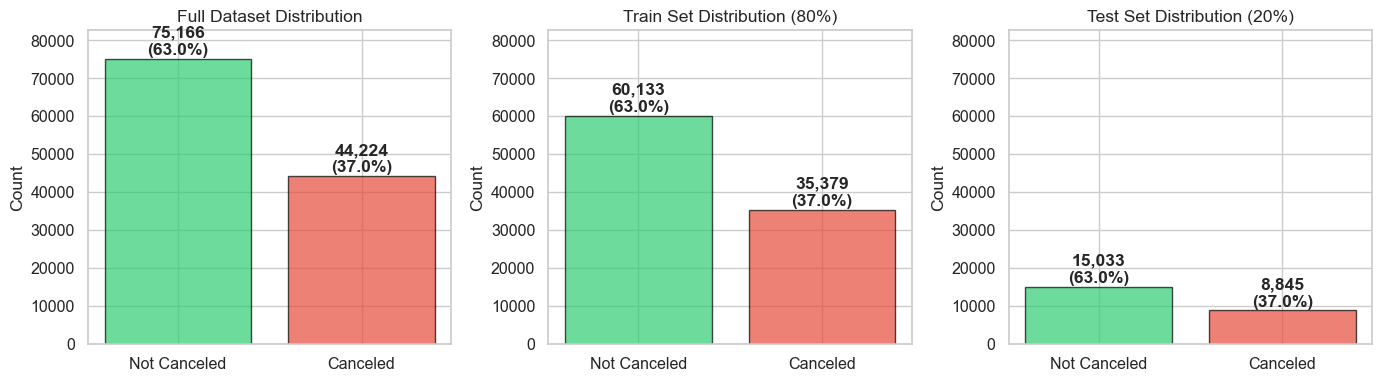

canceled                       1.000000
deposit_Non Refund             0.474012
country_PRT                    0.320796
lead_time_days                 0.290386
market_segment_Groups          0.219832
distribution_channel_TA/TO     0.170695
customer_type_Transient        0.132083
reservation_date_2015-07-06    0.099803
reservation_date_2016-11-25    0.088191
reservation_date_2016-01-18    0.085087
avg_daily_rate                 0.053885


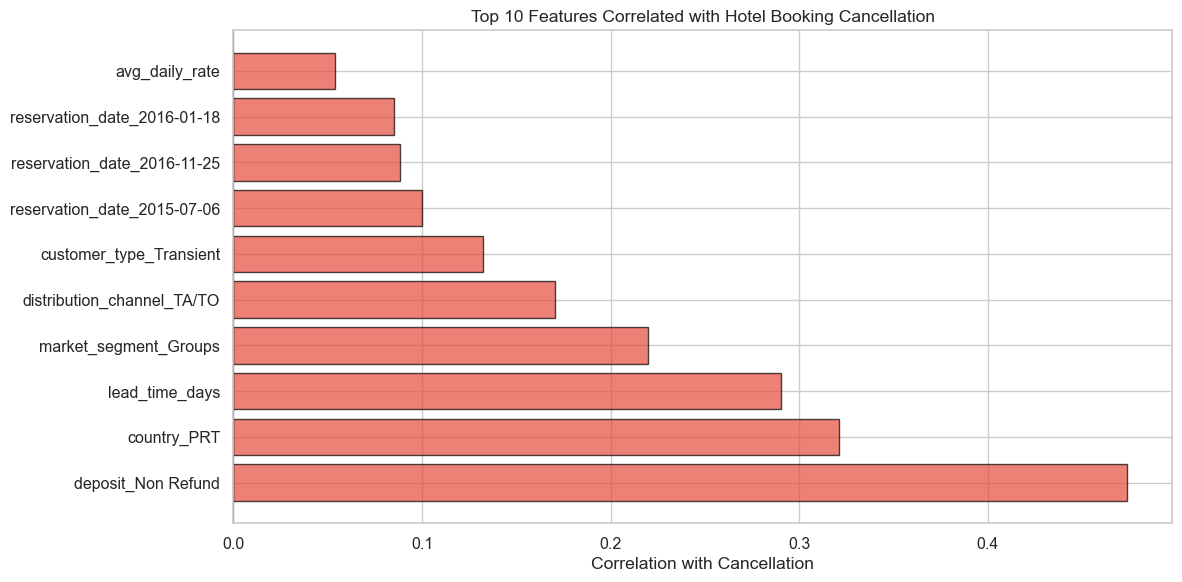

In [21]:
"""
Class Imbalance Detection & Visualization
"""
class_counts = y.value_counts()
class_pct = y.value_counts(normalize=True) * 100
print(f"Not Canceled (0): {class_counts[0]:,} ({class_pct[0]:.2f}%)")
print(f"Canceled (1):     {class_counts[1]:,} ({class_pct[1]:.2f}%)")
print(f"Imbalance Ratio:  1:{class_counts[0]/class_counts[1]:.2f}")

train_counts = y_train.value_counts()
test_counts = y_test.value_counts()
train_pct = y_train.value_counts(normalize=True) * 100
test_pct = y_test.value_counts(normalize=True) * 100

print(f"Not Canceled: {train_counts[0]:,} ({train_pct[0]:.2f}%)")
print(f"Canceled:     {train_counts[1]:,} ({train_pct[1]:.2f}%)")

print(f"Not Canceled: {test_counts[0]:,} ({test_pct[0]:.2f}%)")
print(f"Canceled:     {test_counts[1]:,} ({test_pct[1]:.2f}%)")
imbalance_ratio = class_counts[0] / class_counts[1]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

class_names = ['Not Canceled', 'Canceled']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(class_names, class_counts, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Full Dataset Distribution')
axes[0].set_ylim(0, max(class_counts) * 1.1)
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 1000, f'{v:,}\n({class_pct.iloc[i]:.1f}%)', ha='center', fontweight='bold')

axes[1].bar(class_names, train_counts, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Count')
axes[1].set_title('Train Set Distribution (80%)')
axes[1].set_ylim(0, max(class_counts) * 1.1)
for i, v in enumerate(train_counts):
    axes[1].text(i, v + 1000, f'{v:,}\n({train_pct.iloc[i]:.1f}%)', ha='center', fontweight='bold')

axes[2].bar(class_names, test_counts, color=colors, alpha=0.7, edgecolor='black')
axes[2].set_ylabel('Count')
axes[2].set_title('Test Set Distribution (20%)')
axes[2].set_ylim(0, max(class_counts) * 1.1)
for i, v in enumerate(test_counts):
    axes[2].text(i, v + 1000, f'{v:,}\n({test_pct.iloc[i]:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

correlation_data = X_train_selected.copy()
correlation_data['canceled'] = y_train

corr_with_target = correlation_data.corr()['canceled'].sort_values(ascending=False)
print(corr_with_target.head(11).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
top_corr = corr_with_target.drop('canceled').head(10)
colors_corr = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_corr.values]
ax.barh(range(len(top_corr)), top_corr.values, color=colors_corr, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index)
ax.set_xlabel('Correlation with Cancellation')
ax.set_title('Top 10 Features Correlated with Hotel Booking Cancellation')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

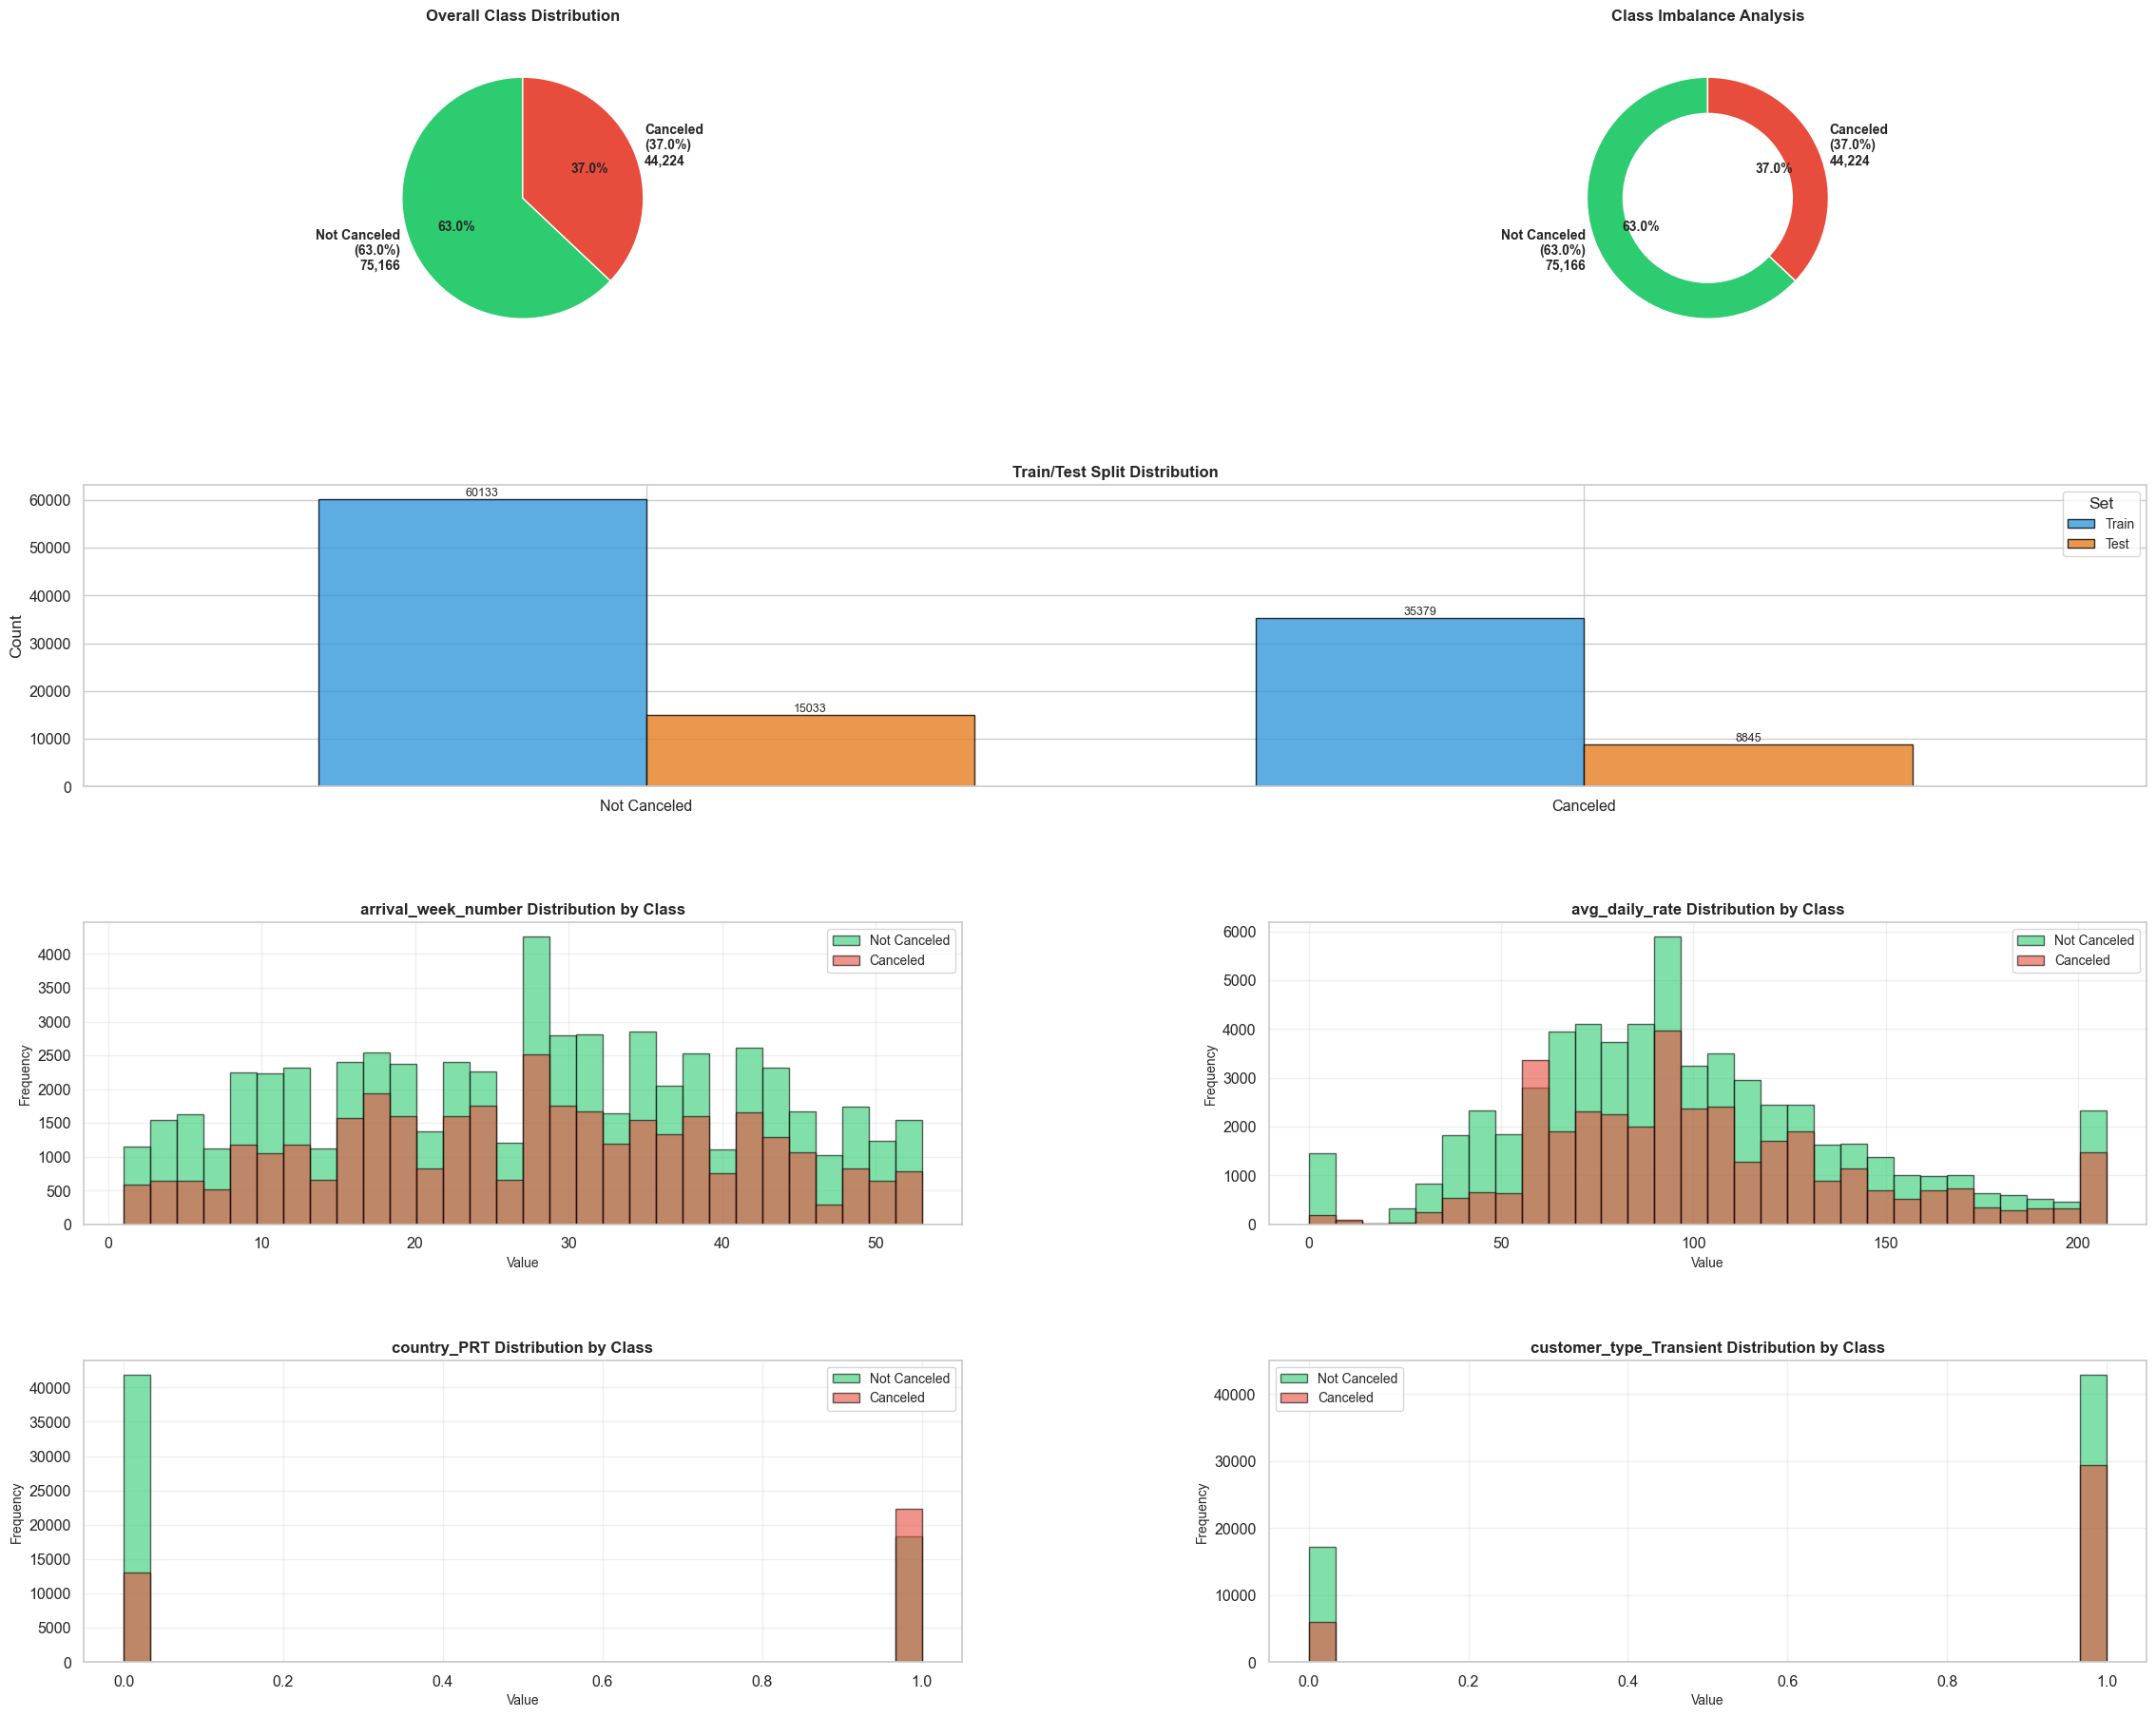

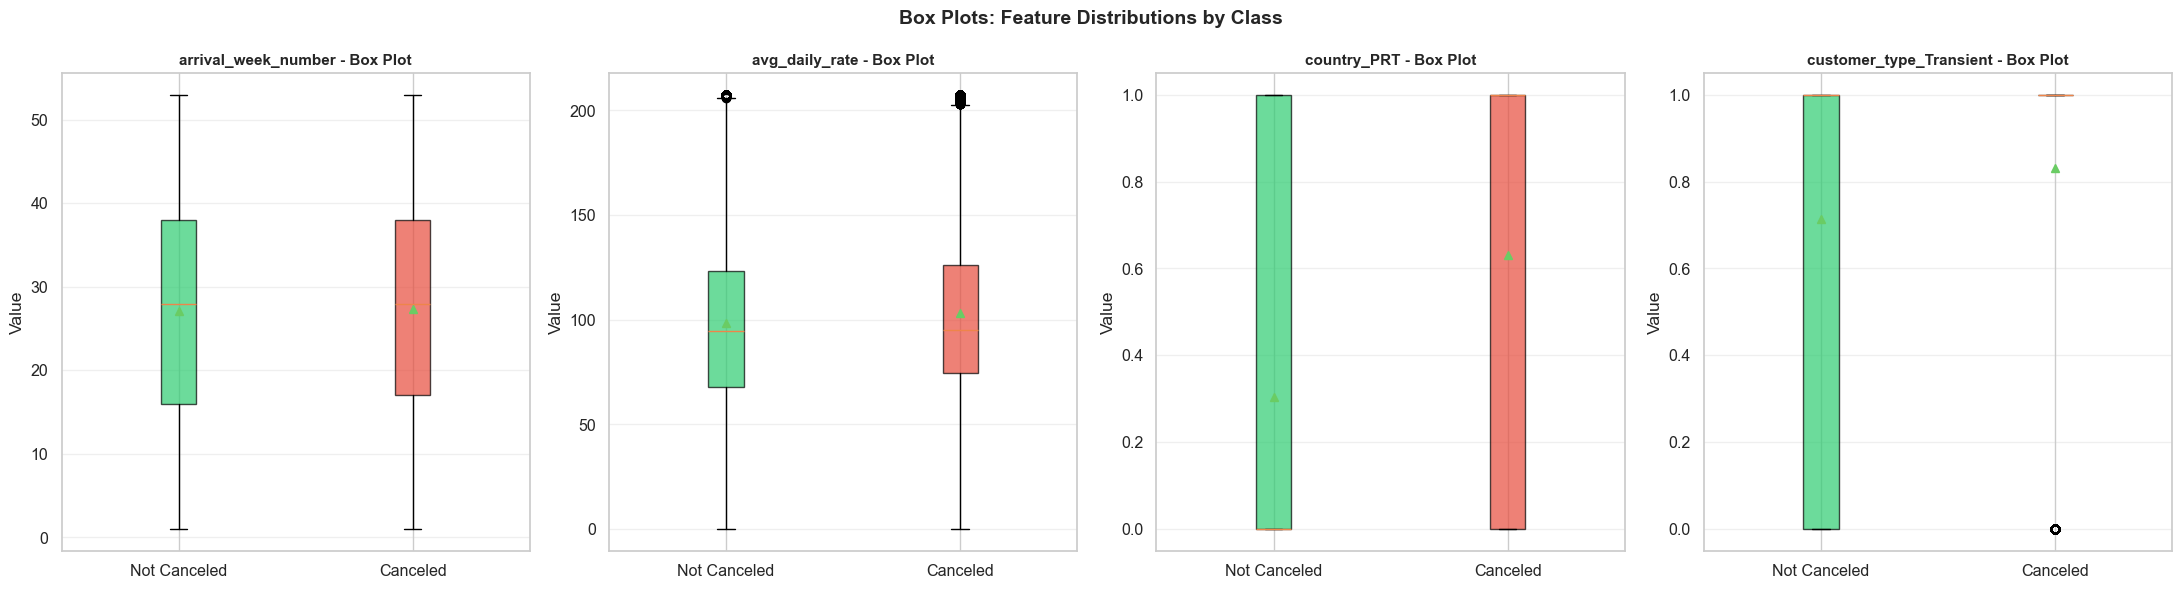

<Figure size 640x480 with 0 Axes>

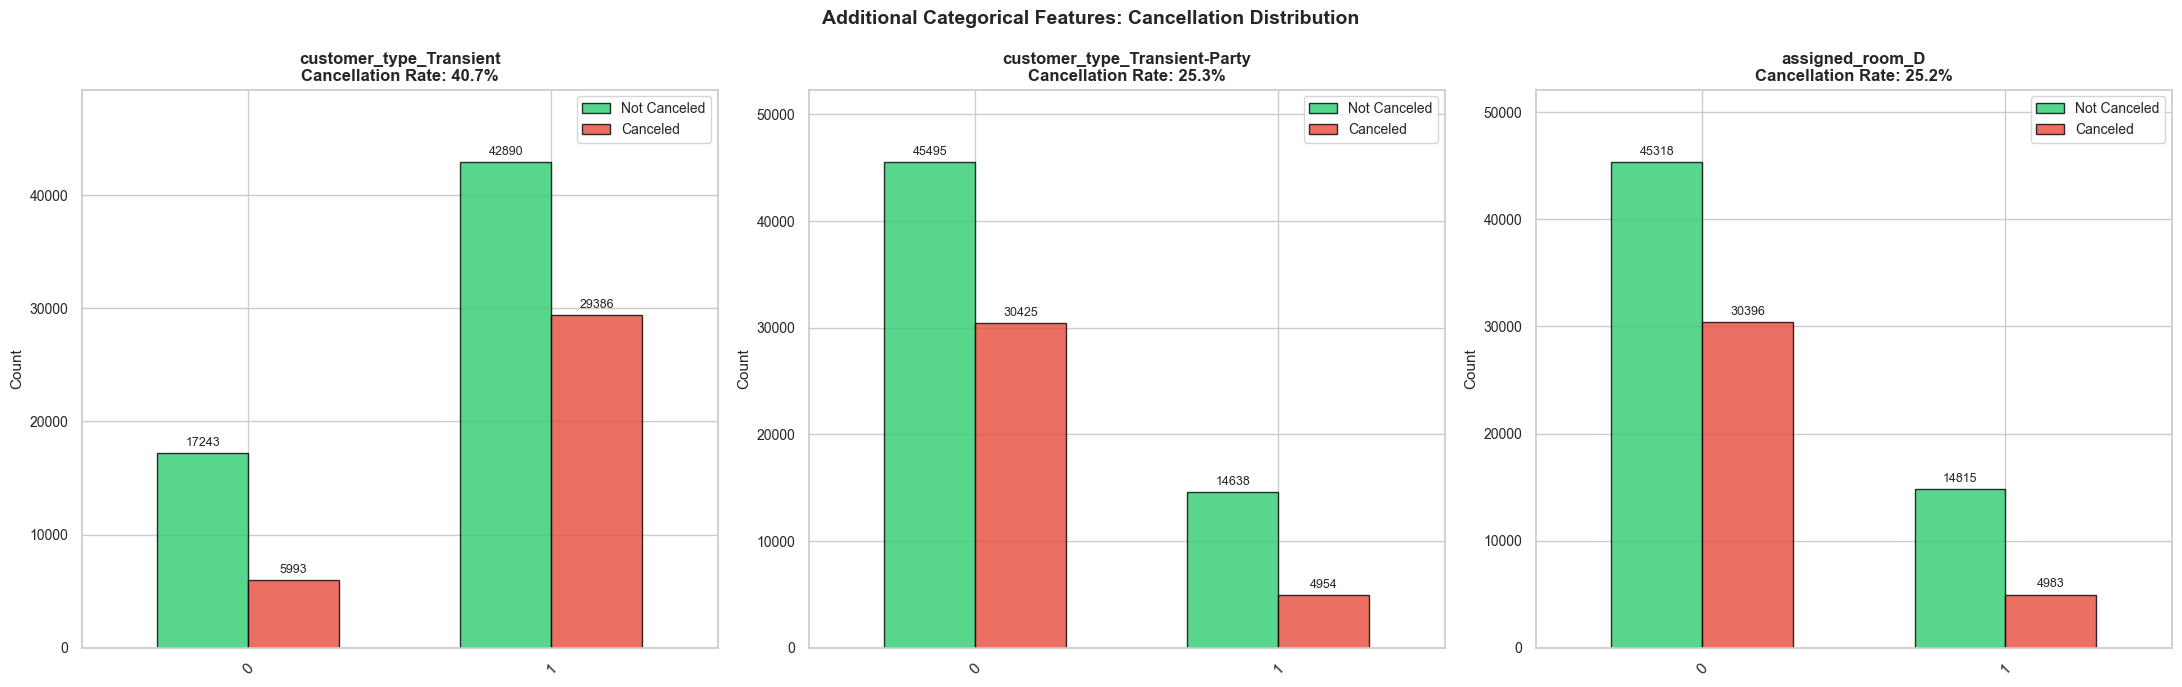

                         mean      std  min   25%   50%    75%    max
adults                 2.0000   0.0000  2.0   2.0   2.0    2.0    2.0
arrival_week_number   27.1847  13.4327  1.0  17.0  28.0   38.0   53.0
assigned_room_D        0.2073   0.4054  0.0   0.0   0.0    0.0    1.0
avg_daily_rate       100.3816  43.7733  0.0  70.0  94.8  125.0  207.5
country_DEU            0.0597   0.2370  0.0   0.0   0.0    0.0    1.0
country_FRA            0.0848   0.2786  0.0   0.0   0.0    0.0    1.0
country_GBR            0.0992   0.2989  0.0   0.0   0.0    0.0    1.0
country_Other          0.1473   0.3544  0.0   0.0   0.0    0.0    1.0
                     Skewness  Kurtosis
adults                 0.0000    0.0000
arrival_week_number   -0.0167   -0.9366
assigned_room_D        1.4443    0.0859
avg_daily_rate         0.5322    0.1896
country_DEU            3.7156   11.8060
country_FRA            2.9802    6.8818
country_GBR            2.6820    5.1930
country_Other          1.9905    1.9622

Missing V

In [22]:
"""
Enhanced Exploratory Data Analysis
Class Imbalance Detection & Visualization
Train / Test Split Analysis
Numeric Feature Distributions by Class
Categorical Feature Cancellation Rates
Feature Variance Analysis
"""
fig = plt.figure(figsize=(28, 40))
gs = fig.add_gridspec(7, 2, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
sizes = [class_counts[0], class_counts[1]]
labels = [f'Not Canceled\n({class_pct[0]:.1f}%)\n{class_counts[0]:,}', 
          f'Canceled\n({class_pct[1]:.1f}%)\n{class_counts[1]:,}']
colors_pie = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax1.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
                                     startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax1.set_title('Overall Class Distribution', fontsize=12, fontweight='bold', pad=20)

ax2 = fig.add_subplot(gs[0, 1])
wedges, texts, autotexts = ax2.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
                                     startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('Class Imbalance Analysis', fontsize=12, fontweight='bold', pad=20)

ax3 = fig.add_subplot(gs[1, :])
split_data = pd.DataFrame({
    'Train': [train_counts[0], train_counts[1]],
    'Test': [test_counts[0], test_counts[1]]
}, index=['Not Canceled', 'Canceled'])
split_data.plot(kind='bar', ax=ax3, color=['#3498db', '#e67e22'], alpha=0.8, edgecolor='black', width=0.7)
ax3.set_title('Train/Test Split Distribution', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count')
ax3.set_xlabel('')
ax3.legend(title='Set', fontsize=10)
ax3.tick_params(axis='x', rotation=0)
for container in ax3.containers:
    ax3.bar_label(container, fmt='%d', fontsize=9)

all_numeric_features = X_train_selected.select_dtypes(include=[np.number]).columns.tolist()
features_to_exclude = {'adults', 'assigned_room_D', 'country_DEU', 'country_FRA', 'country_GBR', 'country_Other'}
numeric_features_sample = [f for f in all_numeric_features if f not in features_to_exclude][:4]

for idx, feature in enumerate(numeric_features_sample):
    row = 2 + (idx // 2)
    col = idx % 2
    ax = fig.add_subplot(gs[row, col])

    not_canceled = X_train_selected[y_train == 0][feature]
    canceled = X_train_selected[y_train == 1][feature]

    ax.hist(not_canceled, bins=30, alpha=0.6, label='Not Canceled', color='#2ecc71', edgecolor='black')
    ax.hist(canceled, bins=30, alpha=0.6, label='Canceled', color='#e74c3c', edgecolor='black')
    ax.set_title(f'{feature} Distribution by Class', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

fig2, axes_box = plt.subplots(1, 4, figsize=(22, 6))
axes_box = axes_box.flatten()

for idx, feature in enumerate(numeric_features_sample):
    data_to_plot = [X_train_selected[y_train == 0][feature], 
                    X_train_selected[y_train == 1][feature]]
    bp = axes_box[idx].boxplot(data_to_plot, labels=['Not Canceled', 'Canceled'],
                               patch_artist=True, showmeans=True)

    for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes_box[idx].set_title(f'{feature} - Box Plot', fontsize=11, fontweight='bold')
    axes_box[idx].set_ylabel('Value')
    axes_box[idx].grid(alpha=0.3, axis='y')

plt.suptitle('Box Plots: Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

cat_features = X_train_selected.select_dtypes(include=['int64', 'uint8']).columns
binary_features = [col for col in cat_features if X_train_selected[col].nunique() <= 2]

features_to_exclude_cat = {'country_GBR', 'country_Other'}
binary_features = [f for f in binary_features if f not in features_to_exclude_cat]

cancellation_rates = {}
for feature in binary_features[:8]:
    feature_canceled = X_train_selected[y_train == 1][feature].sum()
    feature_total = X_train_selected[feature].sum()
    if feature_total > 0:
        cancellation_rates[feature] = (feature_canceled / feature_total * 100) if feature_total > 0 else 0

sorted_features = sorted(cancellation_rates.items(), key=lambda x: x[1], reverse=True)[:2]

for idx, (feature, rate) in enumerate(sorted_features):
    ax = fig.add_subplot(gs[4, idx])
    contingency = pd.crosstab(X_train_selected[feature], y_train)
    contingency.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], 
                    alpha=0.8, edgecolor='black', width=0.5, stacked=False)

    ax.set_title(f'{feature}\nCancellation Rate: {rate:.1f}%', 
                fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=11)
    ax.set_xlabel('')
    ax.legend(['Not Canceled', 'Canceled'], fontsize=10, loc='upper right')
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    ax.tick_params(axis='y', labelsize=10)

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=9, padding=5)

    ax.margins(y=0.2, x=0.1)
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

ax_var = fig.add_subplot(gs[5:, :])
numeric_cols_sample = X_train_selected.select_dtypes(include=[np.number]).columns[:8]
variances = X_train_selected[numeric_cols_sample].var()
variances_sorted = variances.sort_values(ascending=False)
colors_var = plt.cm.RdYlGn(np.linspace(0, 1, len(variances_sorted)))
bars = ax_var.barh(range(len(variances_sorted)), variances_sorted.values, color=colors_var, edgecolor='black')
ax_var.set_yticks(range(len(variances_sorted)))
ax_var.set_yticklabels(variances_sorted.index, fontsize=10)
ax_var.set_xlabel('Variance', fontsize=11, fontweight='bold')
ax_var.set_title('Feature Variance Analysis (First 8 Numeric Features)', fontsize=12, fontweight='bold')
ax_var.grid(alpha=0.3, axis='x')

for idx, (bar, val) in enumerate(zip(bars, variances_sorted.values)):
    ax_var.text(val, idx, f'  {val:.2f}', va='center', fontsize=9)

plt.suptitle('Enhanced Exploratory Data Analysis - Comprehensive Visualizations', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

remaining_features = sorted_features[2:]
if remaining_features or len(sorted_features) >= 2:
    additional_sorted = sorted(cancellation_rates.items(), key=lambda x: x[1], reverse=True)[2:5]

    if additional_sorted:
        fig3, axes_cat = plt.subplots(1, min(3, len(additional_sorted)), figsize=(22, 7))
        if len(additional_sorted) == 1:
            axes_cat = [axes_cat]

        for idx, (feature, rate) in enumerate(additional_sorted):
            ax = axes_cat[idx]
            contingency = pd.crosstab(X_train_selected[feature], y_train)
            contingency.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], 
                            alpha=0.8, edgecolor='black', width=0.6)

            ax.set_title(f'{feature}\nCancellation Rate: {rate:.1f}%', 
                        fontsize=12, fontweight='bold')
            ax.set_ylabel('Count', fontsize=11)
            ax.set_xlabel('')
            ax.legend(['Not Canceled', 'Canceled'], fontsize=10)
            ax.tick_params(axis='x', rotation=45, labelsize=11)
            ax.tick_params(axis='y', labelsize=10)

            for container in ax.containers:
                ax.bar_label(container, fmt='%d', fontsize=9, padding=3)

            ax.margins(y=0.15)

        plt.suptitle('Additional Categorical Features: Cancellation Distribution', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

numeric_cols_sample = X_train_selected.select_dtypes(include=[np.number]).columns[:8]
summary_stats = X_train_selected[numeric_cols_sample].describe().T
print(summary_stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4).to_string())

skewness_kurt = pd.DataFrame({
    'Skewness': X_train_selected[numeric_cols_sample].skew(),
    'Kurtosis': X_train_selected[numeric_cols_sample].kurtosis()
}).round(4)
print(skewness_kurt.to_string())

print(f"\nMissing Values in Training Set:")
missing_count = X_train_selected.isnull().sum().sum()
print(f"  Total missing values: {missing_count}")
print(f"  Completeness: {(1 - missing_count / (X_train_selected.shape[0] * X_train_selected.shape[1])) * 100:.2f}%")

for feature, var in variances.items():
    print(f"  {feature:30s}: {var:15.6f}")

class_means = pd.DataFrame({
    'Not Canceled': X_train_selected[y_train == 0][numeric_cols_sample[:6]].mean(),
    'Canceled': X_train_selected[y_train == 1][numeric_cols_sample[:6]].mean()
})
print(class_means.round(4).to_string())

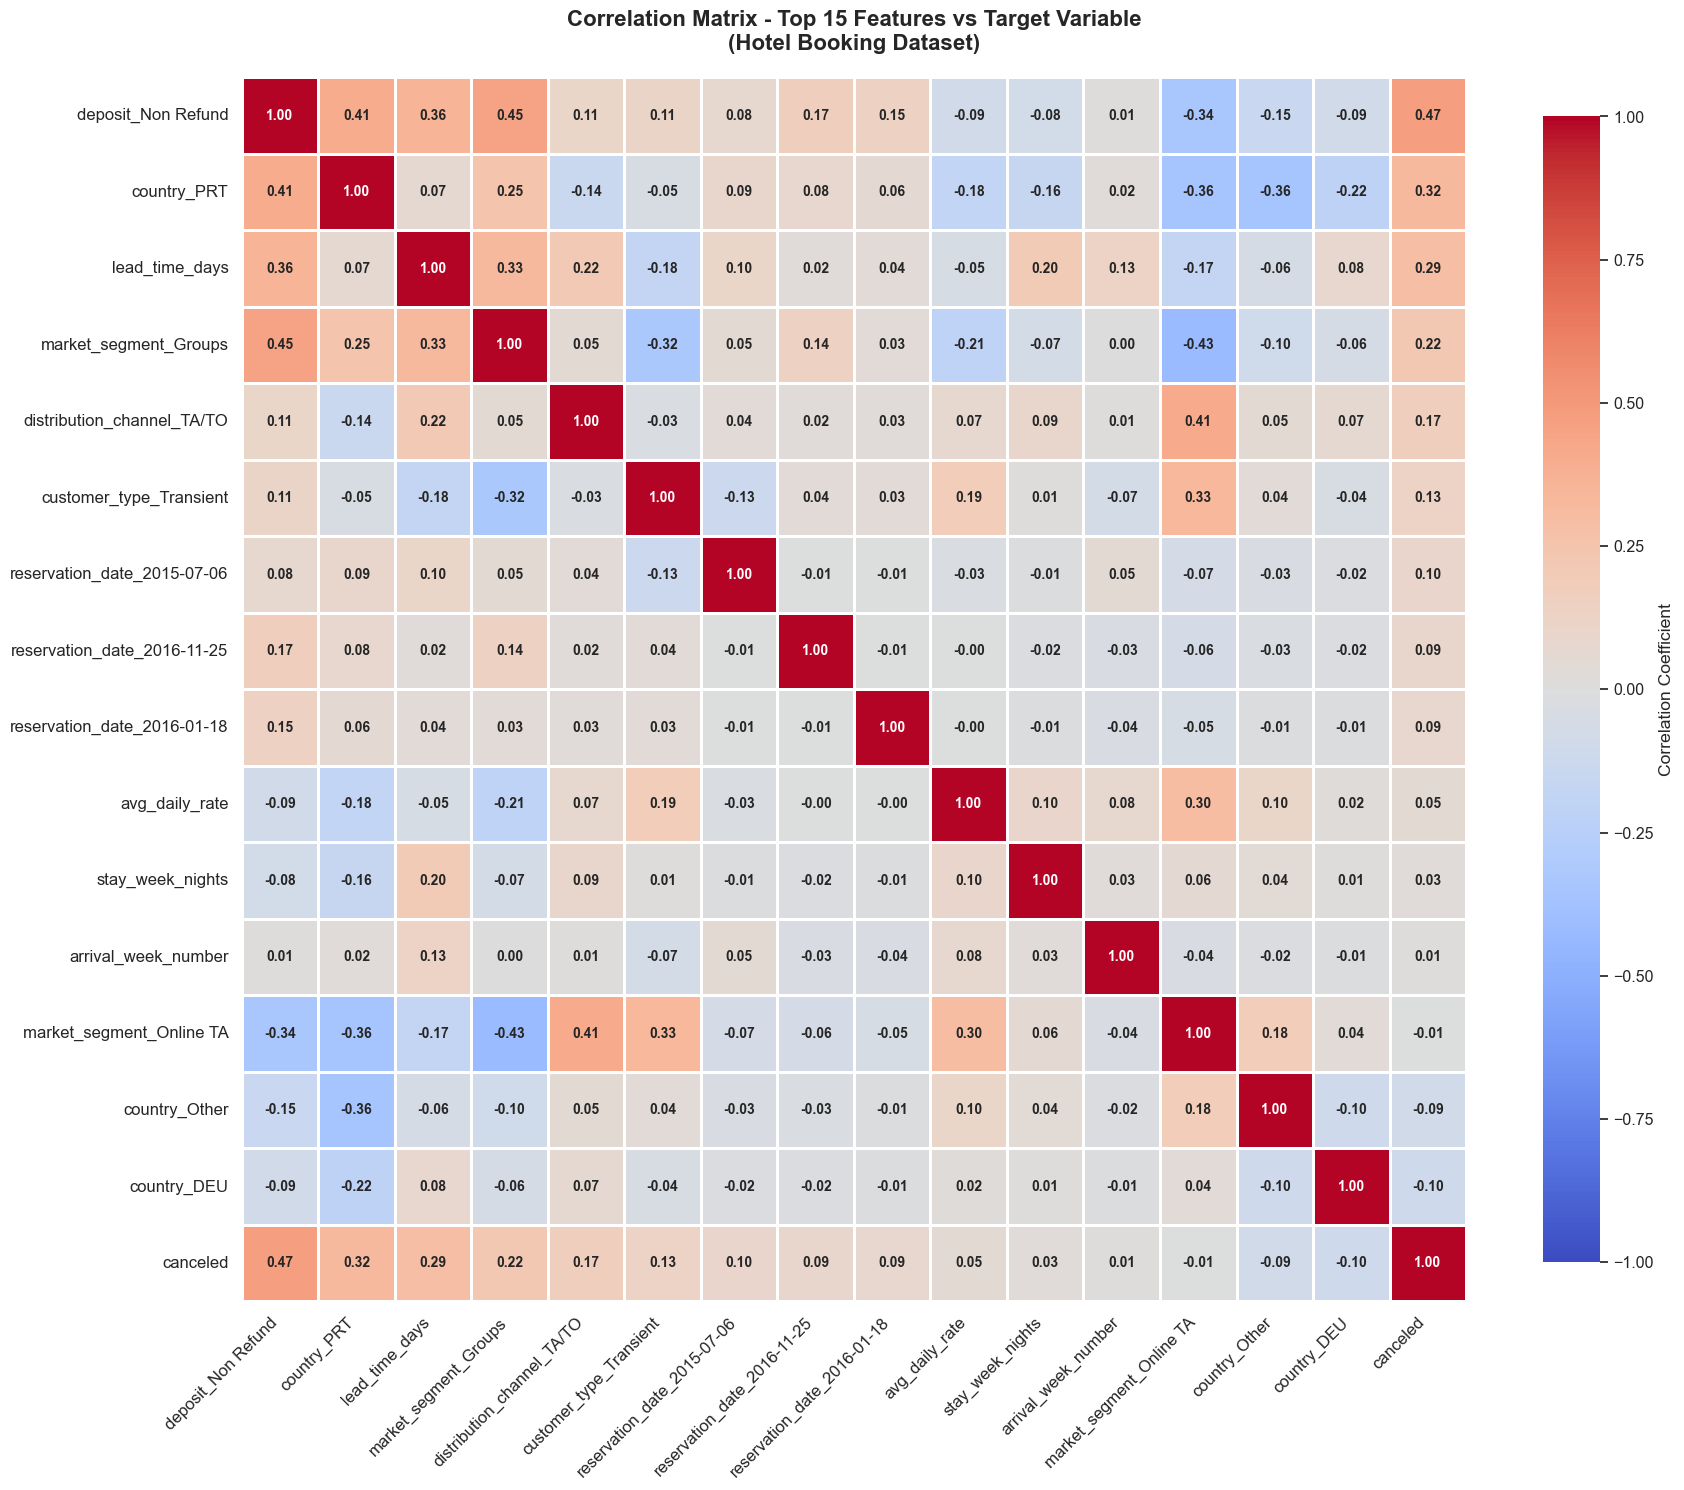

In [23]:
"""
Correlation Matrix - Top 15 Features vs Target Variable
"""
fig, ax = plt.subplots(figsize=(18, 16))

top_15_features = list(corr_with_target.drop('canceled').head(15).index) + ['canceled']
corr_matrix = correlation_data[top_15_features].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            ax=ax, cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8}, 
            vmin=-1, vmax=1, square=True, linewidths=1, annot_kws={'fontsize': 10, 'fontweight': 'bold'},
            cbar=True)

ax.set_title('Correlation Matrix - Top 15 Features vs Target Variable\n(Hotel Booking Dataset)', 
             fontsize=16, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

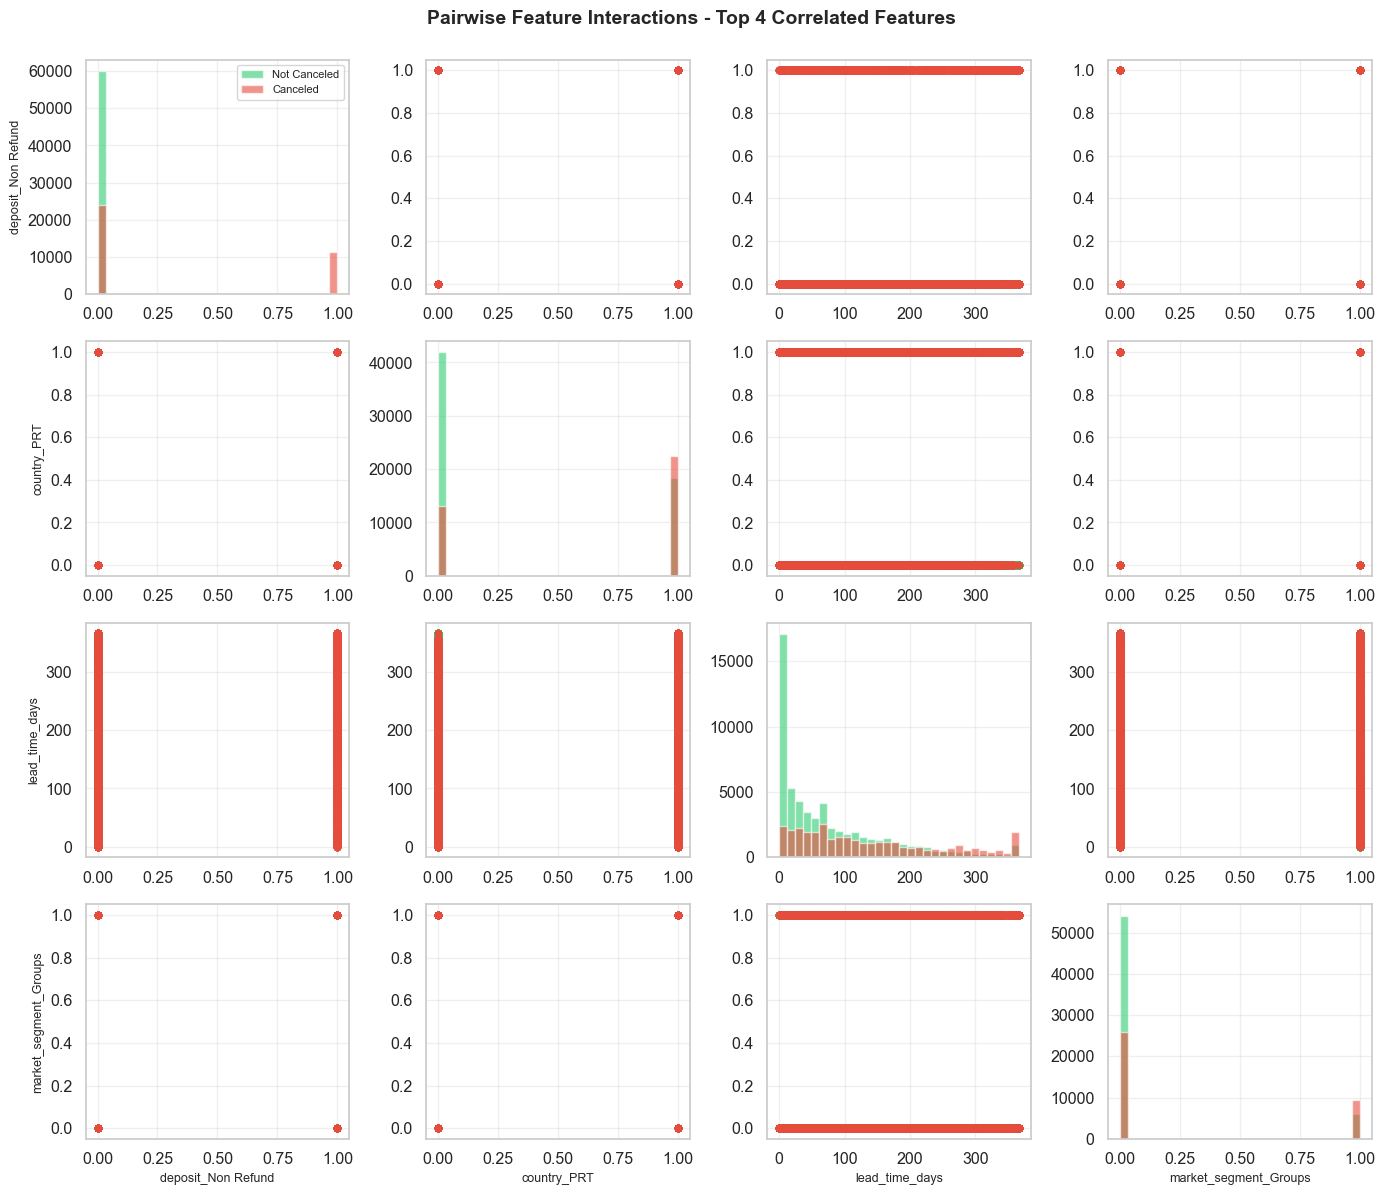

                    Feature      F-Score  P-Value
         deposit_Non Refund 27679.026551      0.0
                country_PRT 10956.454981      0.0
             lead_time_days  8795.449557      0.0
           special_requests  5644.480264      0.0
     reservation_date_Other  5011.903577      0.0
      market_segment_Groups  4849.995266      0.0
 distribution_channel_TA/TO  2866.363190      0.0
      market_segment_Direct  2240.205438      0.0
distribution_channel_Direct  2136.033026      0.0
         hotel_Resort Hotel  1761.134644      0.0


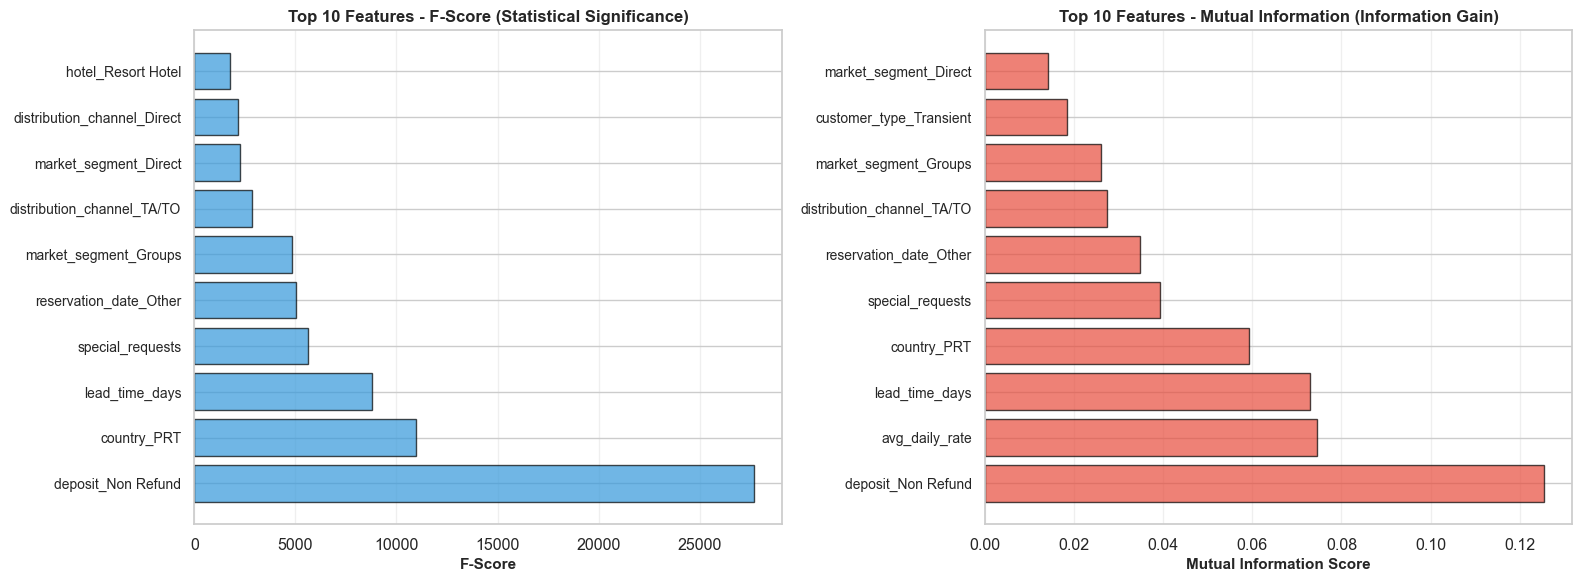

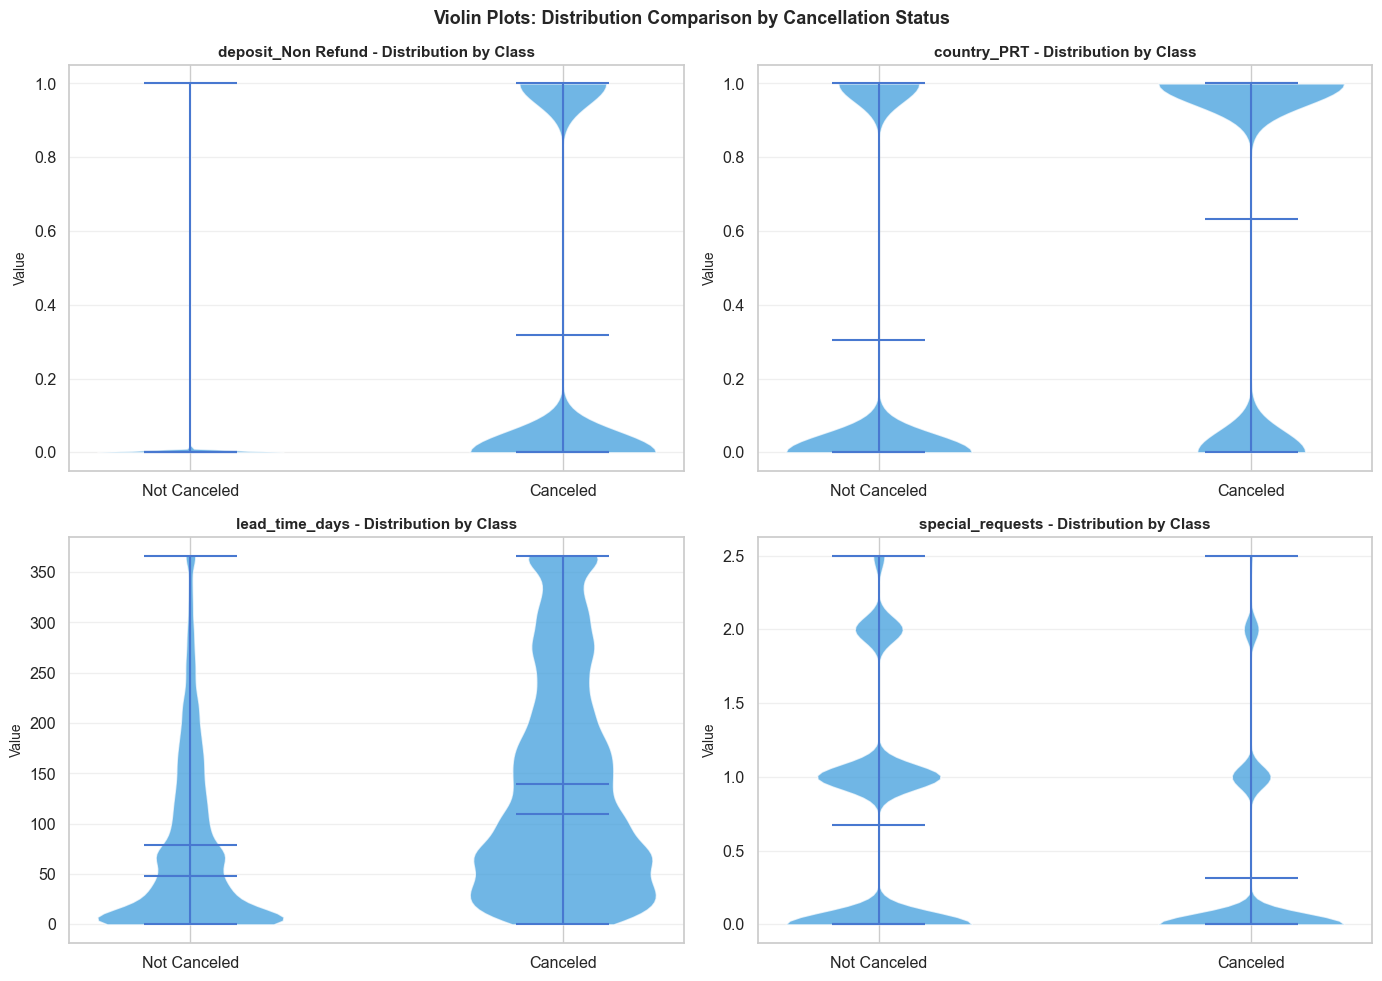

 1. deposit_Non Refund             | Rate(0): 28.63% | Rate(1): 99.33% | Δ: 70.70%
 2. reservation_date_2015-07-06    | Rate(0): 36.65% | Rate(1): 96.91% | Δ: 60.26%
 3. reservation_date_2016-01-18    | Rate(0): 36.75% | Rate(1): 94.98% | Δ: 58.23%
 4. country_PRT                    | Rate(0): 23.72% | Rate(1): 55.05% | Δ: 31.34%
 5. market_segment_Groups          | Rate(0): 32.38% | Rate(1): 61.20% | Δ: 28.83%
 6. market_segment_Direct          | Rate(0): 39.52% | Rate(1): 15.48% | Δ: 24.04%
 7. distribution_channel_Direct    | Rate(0): 39.67% | Rate(1): 17.63% | Δ: 22.04%
 8. distribution_channel_TA/TO     | Rate(0): 19.17% | Rate(1): 40.84% | Δ: 21.68%
 9. country_DEU                    | Rate(0): 38.32% | Rate(1): 16.95% | Δ: 21.37%
10. country_FRA                    | Rate(0): 38.76% | Rate(1): 18.54% | Δ: 20.22%


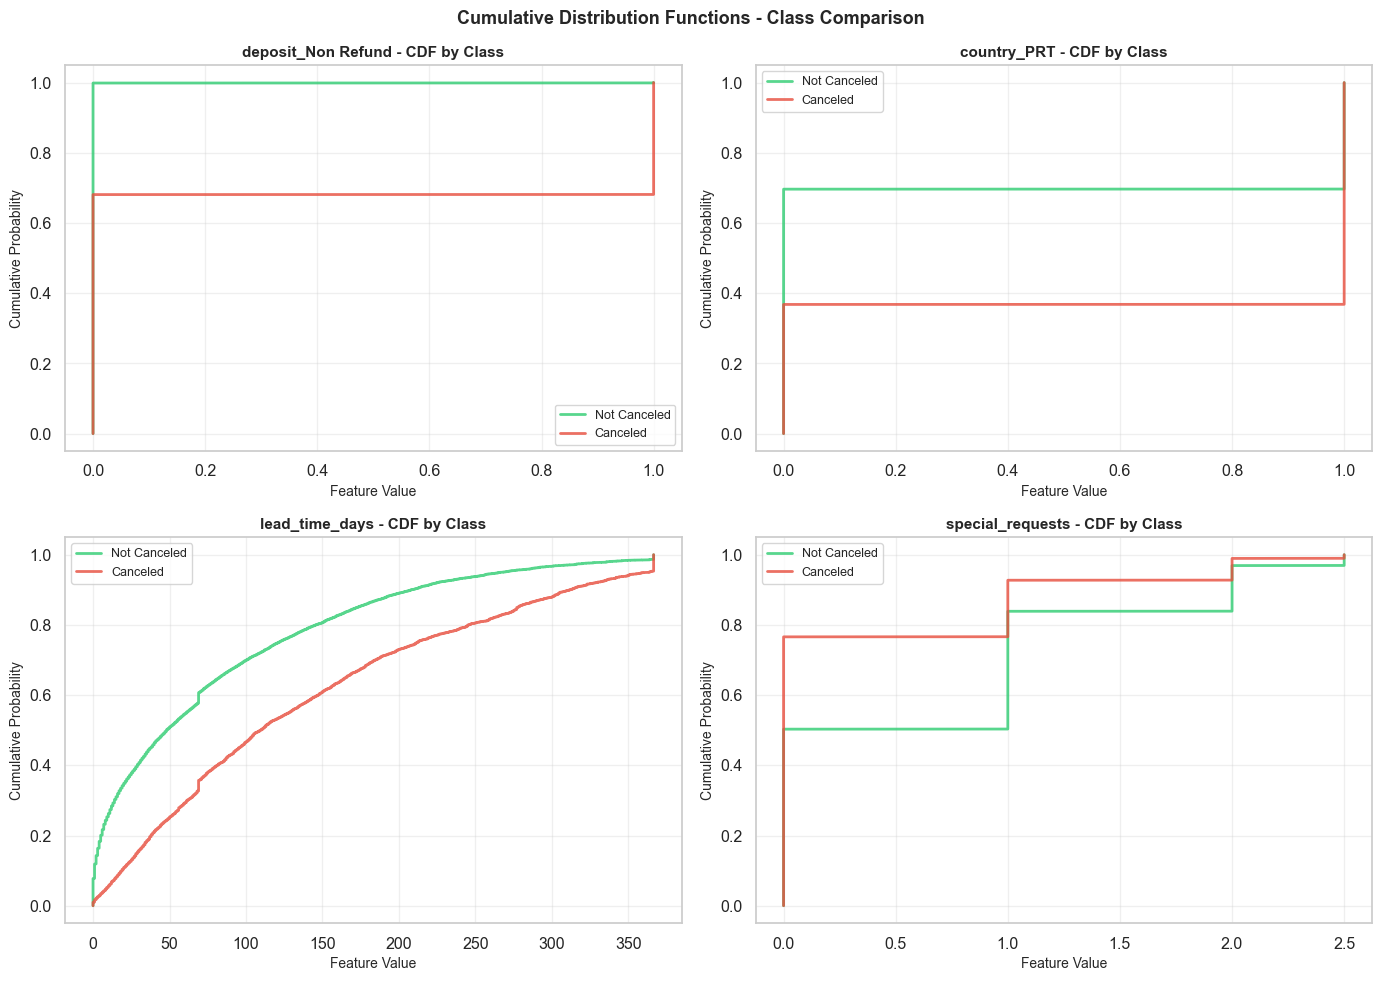

In [24]:
"""
Pairwise Feature Interaction Plots - Top 4 Correlated Features
"""
top_4_features = corr_with_target.drop('canceled').head(4).index.tolist()
pair_data = X_train_selected[top_4_features].copy()
pair_data['canceled'] = y_train

fig_pair = plt.figure(figsize=(14, 12))
n_features = len(top_4_features)

for i in range(n_features):
    for j in range(n_features):
        ax = plt.subplot(n_features, n_features, i * n_features + j + 1)

        if i == j:
            not_canceled = pair_data[pair_data['canceled'] == 0][top_4_features[i]]
            canceled = pair_data[pair_data['canceled'] == 1][top_4_features[i]]

            ax.hist(not_canceled, bins=30, alpha=0.6, label='Not Canceled', color='#2ecc71')
            ax.hist(canceled, bins=30, alpha=0.6, label='Canceled', color='#e74c3c')
            ax.set_ylabel('Frequency')
            if i == 0:
                ax.legend(loc='upper right', fontsize=8)
        else:
            not_canceled_mask = pair_data['canceled'] == 0
            canceled_mask = pair_data['canceled'] == 1

            ax.scatter(pair_data[not_canceled_mask][top_4_features[j]], 
                      pair_data[not_canceled_mask][top_4_features[i]], 
                      alpha=0.5, s=20, color='#2ecc71', label='Not Canceled')
            ax.scatter(pair_data[canceled_mask][top_4_features[j]], 
                      pair_data[canceled_mask][top_4_features[i]], 
                      alpha=0.5, s=20, color='#e74c3c', label='Canceled')

        if j == 0:
            ax.set_ylabel(top_4_features[i], fontsize=9)
        else:
            ax.set_ylabel('')

        if i == n_features - 1:
            ax.set_xlabel(top_4_features[j], fontsize=9)
        else:
            ax.set_xlabel('')

        ax.grid(alpha=0.3)

plt.suptitle('Pairwise Feature Interactions - Top 4 Correlated Features', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

from sklearn.feature_selection import f_classif, mutual_info_classif

f_scores, p_values = f_classif(X_train_selected, y_train)

feature_importance_stats = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'F-Score': f_scores,
    'P-Value': p_values
}).sort_values('F-Score', ascending=False)

print(feature_importance_stats.head(10)[['Feature', 'F-Score', 'P-Value']].to_string(index=False))

fig_imp, axes_imp = plt.subplots(1, 2, figsize=(16, 6))

axes_imp[0].barh(range(10), feature_importance_stats['F-Score'].head(10), 
                 color='#3498db', alpha=0.7, edgecolor='black')
axes_imp[0].set_yticks(range(10))
axes_imp[0].set_yticklabels(feature_importance_stats['Feature'].head(10), fontsize=10)
axes_imp[0].set_xlabel('F-Score', fontsize=11, fontweight='bold')
axes_imp[0].set_title('Top 10 Features - F-Score (Statistical Significance)', 
                     fontsize=12, fontweight='bold')
axes_imp[0].grid(alpha=0.3, axis='x')

mi_scores = mutual_info_classif(X_train_selected, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'MI-Score': mi_scores
}).sort_values('MI-Score', ascending=False)

axes_imp[1].barh(range(10), mi_df['MI-Score'].head(10), 
                 color='#e74c3c', alpha=0.7, edgecolor='black')
axes_imp[1].set_yticks(range(10))
axes_imp[1].set_yticklabels(mi_df['Feature'].head(10), fontsize=10)
axes_imp[1].set_xlabel('Mutual Information Score', fontsize=11, fontweight='bold')
axes_imp[1].set_title('Top 10 Features - Mutual Information (Information Gain)', 
                     fontsize=12, fontweight='bold')
axes_imp[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

fig_violin, axes_violin = plt.subplots(2, 2, figsize=(14, 10))
axes_violin = axes_violin.flatten()

top_features_violin = feature_importance_stats['Feature'].head(4)

for idx, feature in enumerate(top_features_violin):
    parts = axes_violin[idx].violinplot(
        [X_train_selected[y_train == 0][feature].values,
         X_train_selected[y_train == 1][feature].values],
        positions=[1, 2],
        showmeans=True,
        showmedians=True
    )

    for pc in parts['bodies']:
        pc.set_facecolor('#3498db')
        pc.set_alpha(0.7)

    axes_violin[idx].set_xticks([1, 2])
    axes_violin[idx].set_xticklabels(['Not Canceled', 'Canceled'])
    axes_violin[idx].set_ylabel('Value', fontsize=10)
    axes_violin[idx].set_title(f'{feature} - Distribution by Class', fontsize=11, fontweight='bold')
    axes_violin[idx].grid(alpha=0.3, axis='y')

plt.suptitle('Violin Plots: Distribution Comparison by Cancellation Status', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

cancellation_diffs = {}

for feature in binary_features[:15]:
    rate_0 = y_train[X_train_selected[feature] == 0].mean() if (X_train_selected[feature] == 0).sum() > 0 else 0
    rate_1 = y_train[X_train_selected[feature] == 1].mean() if (X_train_selected[feature] == 1).sum() > 0 else 0

    cancellation_diffs[feature] = abs(rate_1 - rate_0)

sorted_diffs = sorted(cancellation_diffs.items(), key=lambda x: x[1], reverse=True)

for idx, (feature, diff) in enumerate(sorted_diffs[:10], 1):
    rate_0 = y_train[X_train_selected[feature] == 0].mean() if (X_train_selected[feature] == 0).sum() > 0 else 0
    rate_1 = y_train[X_train_selected[feature] == 1].mean() if (X_train_selected[feature] == 1).sum() > 0 else 0
    print(f"{idx:2d}. {feature:30s} | Rate(0): {rate_0:6.2%} | Rate(1): {rate_1:6.2%} | Δ: {diff:6.2%}")

fig_cdf, axes_cdf = plt.subplots(2, 2, figsize=(14, 10))
axes_cdf = axes_cdf.flatten()

for idx, feature in enumerate(feature_importance_stats['Feature'].head(4)):
    not_canceled_sorted = np.sort(X_train_selected[y_train == 0][feature])
    canceled_sorted = np.sort(X_train_selected[y_train == 1][feature])

    not_canceled_cdf = np.arange(1, len(not_canceled_sorted) + 1) / len(not_canceled_sorted)
    canceled_cdf = np.arange(1, len(canceled_sorted) + 1) / len(canceled_sorted)

    axes_cdf[idx].plot(not_canceled_sorted, not_canceled_cdf, label='Not Canceled', 
                       color='#2ecc71', linewidth=2, alpha=0.8)
    axes_cdf[idx].plot(canceled_sorted, canceled_cdf, label='Canceled', 
                       color='#e74c3c', linewidth=2, alpha=0.8)

    axes_cdf[idx].set_xlabel('Feature Value', fontsize=10)
    axes_cdf[idx].set_ylabel('Cumulative Probability', fontsize=10)
    axes_cdf[idx].set_title(f'{feature} - CDF by Class', fontsize=11, fontweight='bold')
    axes_cdf[idx].legend(fontsize=9)
    axes_cdf[idx].grid(alpha=0.3)

plt.suptitle('Cumulative Distribution Functions - Class Comparison', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 2c: Promising Supervised Learning Algorithms

In [25]:
"""
Baseline Model Evaluation with Cross-Validation 5-Fold
Using stratified sampling to maintain class distribution
"""
baseline_models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=500, solver='lbfgs'),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=8),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, max_depth=12),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE, max_depth=5),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, max_depth=5, learning_rate=0.1, n_jobs=-1, use_label_encoder=False, eval_metric='logloss'),
}

train_sample_size = int(0.50 * len(X_train_selected))
print(f"\nUsing stratified sample of {train_sample_size:,} rows (50% of {len(X_train_selected):,}) for CV")

from sklearn.model_selection import train_test_split as tts
X_train_sample, _, y_train_sample, _ = tts(
    X_train_selected, y_train, 
    train_size=train_sample_size, 
    random_state=RANDOM_STATE, 
    stratify=y_train
)

X_train_sample_scaled = scaler.transform(X_train_sample)
X_train_sample_scaled = pd.DataFrame(X_train_sample_scaled, columns=top_features, index=X_train_sample.index)

cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name, model in baseline_models.items():
    if model_name in ['Logistic Regression', 'KNN']:
        X_cv = X_train_sample_scaled
    else:
        X_cv = X_train_sample

    print(f"\n{model_name}...", end=" ")

    cv_acc = cross_val_score(model, X_cv, y_train_sample, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_f1 = cross_val_score(model, X_cv, y_train_sample, cv=skf, scoring='f1', n_jobs=-1)
    cv_roc = cross_val_score(model, X_cv, y_train_sample, cv=skf, scoring='roc_auc', n_jobs=-1)

    cv_results[model_name] = {
        'Accuracy': cv_acc.mean(),
        'Accuracy_std': cv_acc.std(),
        'F1': cv_f1.mean(),
        'F1_std': cv_f1.std(),
        'ROC-AUC': cv_roc.mean(),
        'ROC-AUC_std': cv_roc.std(),
    }

    print(f"Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
    print(f"F1-Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
    print(f"ROC-AUC:  {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")

cv_results_df = pd.DataFrame(cv_results).T
print(cv_results_df.round(4))

best_model_name = cv_results_df['F1'].idxmax()
print(f"\n✓ Best model (by F1-score): {best_model_name}")
print(f"  F1-Score: {cv_results_df.loc[best_model_name, 'F1']:.4f} ± {cv_results_df.loc[best_model_name, 'F1_std']:.4f}")


Using stratified sample of 47,756 rows (50% of 95,512) for CV

Logistic Regression... Accuracy: 0.7843 ± 0.0032
F1-Score: 0.6625 ± 0.0066
ROC-AUC:  0.8517 ± 0.0052

Decision Tree... Accuracy: 0.8038 ± 0.0056
F1-Score: 0.7305 ± 0.0088
ROC-AUC:  0.8803 ± 0.0057

Random Forest... Accuracy: 0.8259 ± 0.0078
F1-Score: 0.7454 ± 0.0118
ROC-AUC:  0.9029 ± 0.0056

KNN... Accuracy: 0.8069 ± 0.0052
F1-Score: 0.7275 ± 0.0067
ROC-AUC:  0.8647 ± 0.0048

Gradient Boosting... Accuracy: 0.8226 ± 0.0060
F1-Score: 0.7448 ± 0.0100
ROC-AUC:  0.8998 ± 0.0050

XGBoost... Accuracy: 0.8203 ± 0.0082
F1-Score: 0.7412 ± 0.0130
ROC-AUC:  0.8970 ± 0.0065
                     Accuracy  Accuracy_std      F1  F1_std  ROC-AUC  \
Logistic Regression    0.7843        0.0032  0.6625  0.0066   0.8517   
Decision Tree          0.8038        0.0056  0.7305  0.0088   0.8803   
Random Forest          0.8259        0.0078  0.7454  0.0118   0.9029   
KNN                    0.8069        0.0052  0.7275  0.0067   0.8647   
Gradien

## Step 3b: Hyperparameter Tuning with GridSearchCV

In [26]:
"""
Hyperparameter Tuning with GridSearchCV
"""

param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [500, 1000]
    },
    'Decision Tree': {
        'max_depth': [5, 8, 12],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 150],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 150],
        'learning_rate': [0.05, 0.1],
        'max_depth': [4, 5, 6],
    },
    'XGBoost': {
        'n_estimators': [100, 150],
        'learning_rate': [0.05, 0.1],
        'max_depth': [4, 5],
    }
}

grid_results = {}
best_models = {}

for model_name in baseline_models.keys():
    print(f"\nTuning {model_name}...", end=" ")

    model = baseline_models[model_name]
    param_grid = param_grids[model_name]

    if model_name in ['Logistic Regression', 'KNN']:
        X_grid = X_train_scaled
    else:
        X_grid = X_train_selected

    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_grid, y_train)

    best_models[model_name] = grid_search.best_estimator_
    grid_results[model_name] = {
        'Best F1': grid_search.best_score_,
        'Best Params': grid_search.best_params_
    }

    print(f"✓ (Best F1: {grid_search.best_score_:.4f})")
    print(f"   Best params: {grid_search.best_params_}")

for model_name, results in grid_results.items():
    print(f"\n{model_name}:")
    print(f"  Best F1-Score: {results['Best F1']:.4f}")
    print(f"  Best Parameters: {results['Best Params']}")


Tuning Logistic Regression... ✓ (Best F1: 0.6648)
   Best params: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}

Tuning Decision Tree... ✓ (Best F1: 0.7488)
   Best params: {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 10}

Tuning Random Forest... ✓ (Best F1: 0.7862)
   Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 150}

Tuning KNN... ✓ (Best F1: 0.7678)
   Best params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}

Tuning Gradient Boosting... ✓ (Best F1: 0.7659)
   Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 150}

Tuning XGBoost... ✓ (Best F1: 0.7505)
   Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}

Logistic Regression:
  Best F1-Score: 0.6648
  Best Parameters: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}

Decision Tree:
  Best F1-Score: 0.7488
  Best Parameters: {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 10}

Random Forest:
  Best F1-Score: 0

## Step 3c: Learning Curves for Selected Models

Top 4 models: ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Decision Tree']

Random Forest... 
Gradient Boosting... 
XGBoost... 
Decision Tree... 

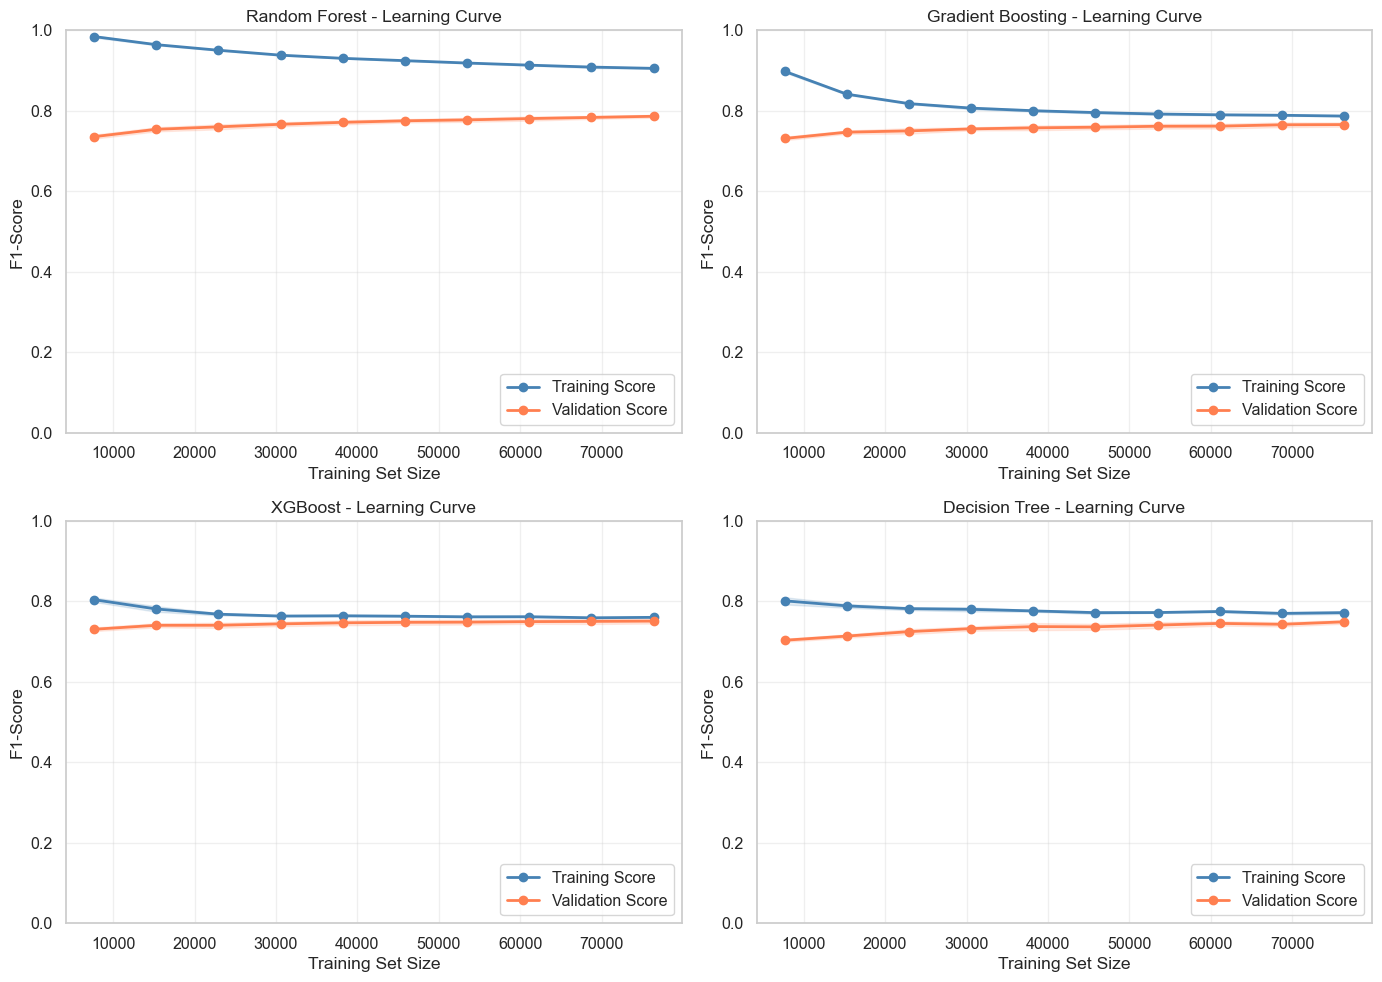

In [27]:
"""
Learning Curve Visualization for Top 4 Models
"""
top_models_list = cv_results_df.nlargest(4, 'F1').index.tolist()
print(f"Top 4 models: {top_models_list}")

train_sizes = np.linspace(0.1, 1.0, 10)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, model_name in enumerate(top_models_list):
    print(f"\n{model_name}...", end=" ")

    model = best_models[model_name]

    if model_name in ['Logistic Regression', 'KNN']:
        X_lc = X_train_scaled
    else:
        X_lc = X_train_selected

    train_sizes_abs, train_scores, val_scores = learning_curve(
        model,
        X_lc,
        y_train,
        cv=5,
        n_jobs=-1,
        scoring='f1',
        train_sizes=train_sizes,
        random_state=RANDOM_STATE
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    ax = axes[idx]
    ax.plot(train_sizes_abs, train_mean, 'o-', color='steelblue', label='Training Score', linewidth=2)
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
    ax.plot(train_sizes_abs, val_mean, 'o-', color='coral', label='Validation Score', linewidth=2)
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color='coral')

    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1-Score')
    ax.set_title(f'{model_name} - Learning Curve')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.show()

## Step 4: Train and Evaluate Best Classifier

Train the best-performing classifier on the full training set and evaluate on the test set.

In [28]:
"""
Train and Evaluate Best Model on Test Set
"""
best_clf = baseline_models[best_model_name]

if best_model_name in ['Logistic Regression', 'SVM', 'KNN']:
    X_train_best = X_train_scaled
    X_test_best = X_test_scaled
else:
    X_train_best = X_train_selected
    X_test_best = X_test_selected

best_clf.fit(X_train_best, y_train)

y_pred_best = best_clf.predict(X_test_best)
y_pred_proba_best = best_clf.predict_proba(X_test_best)[:, 1] if hasattr(best_clf, 'predict_proba') else None

accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_proba_best) if y_pred_proba_best is not None else None

print(f"Best Classifier: {best_model_name}")
print(f"Accuracy:  {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall:    {recall_best:.4f}")
print(f"F1-Score:  {f1_best:.4f}")
print(f"ROC-AUC:   {roc_auc_best:.4f}")

print(classification_report(y_test, y_pred_best, target_names=['Not Canceled', 'Canceled']))

cm_best = confusion_matrix(y_test, y_pred_best)
print(cm_best)

Best Classifier: Random Forest
Accuracy:  0.8303
Precision: 0.8144
Recall:    0.7018
F1-Score:  0.7539
ROC-AUC:   0.9060
              precision    recall  f1-score   support

Not Canceled       0.84      0.91      0.87     15033
    Canceled       0.81      0.70      0.75      8845

    accuracy                           0.83     23878
   macro avg       0.83      0.80      0.81     23878
weighted avg       0.83      0.83      0.83     23878

[[13618  1415]
 [ 2638  6207]]


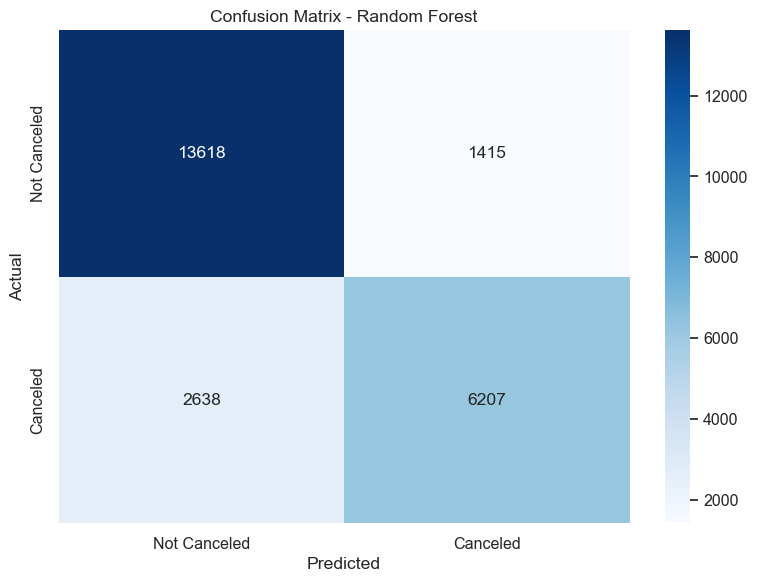

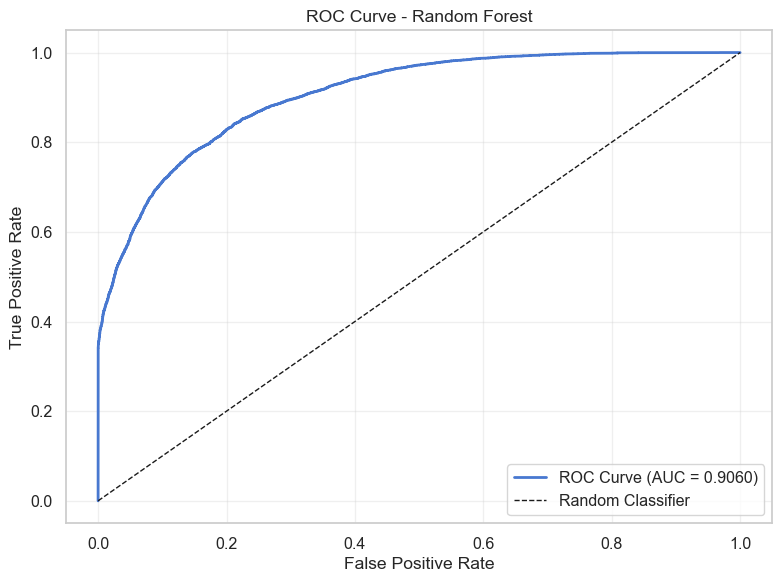

In [29]:
"""
Confusion Matrix Visualization for Best Model
"""
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'],
            ax=ax)
ax.set_title(f'Confusion Matrix - {best_model_name}')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

if y_pred_proba_best is not None:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_best:.4f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {best_model_name}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Step 5: Gradient Boosting Classifier

Train a Gradient Boosting classifier with hyperparameter tuning for comparison with the best baseline model.

In [30]:
"""
Gradient Boosting Classifier with Hyperparameter Tuning using GridSearchCV
"""
gb_clf = GradientBoostingClassifier(random_state=RANDOM_STATE)

gb_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
}

gb_grid_search = GridSearchCV(
    gb_clf, 
    gb_param_grid, 
    cv=3,
    scoring='f1', 
    n_jobs=-1, 
    verbose=1
)

gb_grid_search.fit(X_train_sample, y_train_sample)

print(f"\nBest parameters (from sample): {gb_grid_search.best_params_}")
print(f"Best CV F1-Score (on sample): {gb_grid_search.best_score_:.4f}")

best_gb_params = gb_grid_search.best_params_
gb_clf_best = GradientBoostingClassifier(random_state=RANDOM_STATE, **best_gb_params)
gb_clf_best.fit(X_train_selected, y_train)

y_pred_gb = gb_clf_best.predict(X_test_selected)
y_pred_proba_gb = gb_clf_best.predict_proba(X_test_selected)[:, 1]

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_pred_proba_gb)

print(f"\nGradient Boosting Classifier Results:")
print(f"Accuracy:  {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall:    {recall_gb:.4f}")
print(f"F1-Score:  {f1_gb:.4f}")
print(f"ROC-AUC:   {roc_auc_gb:.4f}")

print(classification_report(y_test, y_pred_gb, target_names=['Not Canceled', 'Canceled']))

cm_gb = confusion_matrix(y_test, y_pred_gb)
print(cm_gb)

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters (from sample): {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
Best CV F1-Score (on sample): 0.7534

Gradient Boosting Classifier Results:
Accuracy:  0.8312
Precision: 0.8085
Recall:    0.7134
F1-Score:  0.7580
ROC-AUC:   0.9066
              precision    recall  f1-score   support

Not Canceled       0.84      0.90      0.87     15033
    Canceled       0.81      0.71      0.76      8845

    accuracy                           0.83     23878
   macro avg       0.83      0.81      0.81     23878
weighted avg       0.83      0.83      0.83     23878

[[13538  1495]
 [ 2535  6310]]


## Step 6: Final Comparison & Evaluation Metrics

Compare the best baseline classifier with the Gradient Boosting classifier using comprehensive evaluation metrics.

                      Feature  Importance
           deposit_Non Refund    0.444087
               lead_time_days    0.115476
     market_segment_Online TA    0.113517
                  country_PRT    0.089732
             special_requests    0.081259
               avg_daily_rate    0.047412
      customer_type_Transient    0.024177
          arrival_week_number    0.019181
customer_type_Transient-Party    0.011830
             stay_week_nights    0.010768
           hotel_Resort Hotel    0.005656
                  country_DEU    0.005438
   distribution_channel_TA/TO    0.005318
              assigned_room_D    0.004699
        market_segment_Direct    0.004465


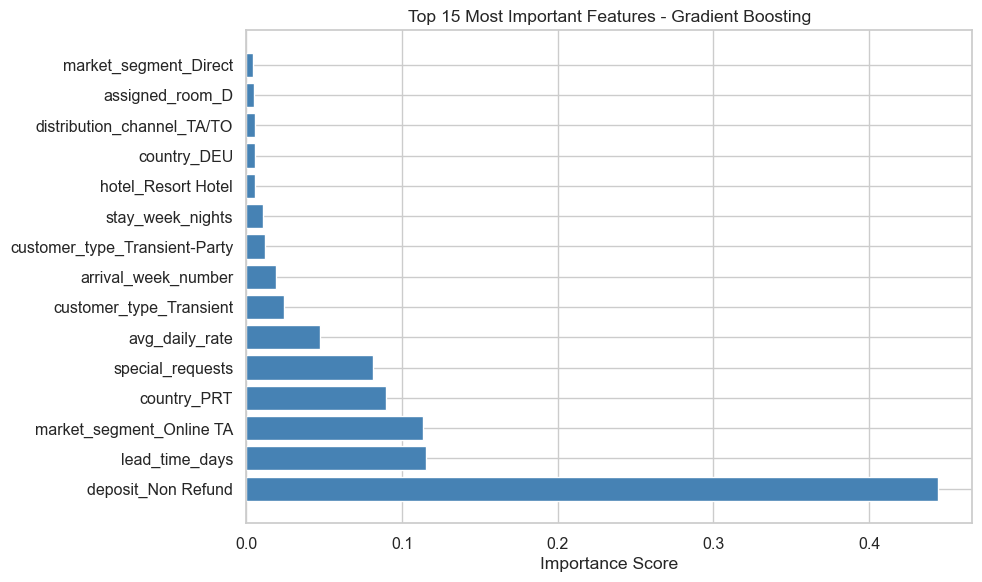


  Test Set Metrics:
    - Accuracy:  0.8312
    - Precision: 0.8085
    - Recall:    0.7134
    - F1-Score:  0.7580
    - ROC-AUC:   0.8070



In [31]:
feature_importance = gb_clf_best.feature_importances_
feature_names = X_train_selected.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print(importance_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(range(15), importance_df['Importance'].head(15), color='steelblue')
plt.yticks(range(15), importance_df['Feature'].head(15))
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Features - Gradient Boosting')
plt.tight_layout()
plt.show()

print(f"""
  Test Set Metrics:
    - Accuracy:  {(accuracy_score(y_test, y_pred_gb)):.4f}
    - Precision: {(precision_score(y_test, y_pred_gb)):.4f}
    - Recall:    {(recall_score(y_test, y_pred_gb)):.4f}
    - F1-Score:  {(f1_score(y_test, y_pred_gb)):.4f}
    - ROC-AUC:   {(roc_auc_score(y_test, y_pred_gb)):.4f}
""")

In [32]:
"""
Comparison of Multiple Models on Test Set
"""
comparison_data = {}

y_pred_gb = gb_clf_best.predict(X_test_selected)
y_pred_proba_gb = gb_clf_best.predict_proba(X_test_selected)[:, 1]

comparison_data['Gradient Boosting'] = {
    'y_pred': y_pred_gb,
    'y_pred_proba': y_pred_proba_gb,
    'model': gb_clf_best,
    'color': '#2ecc71'  # Green
}

dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10)
dt_clf.fit(X_train_selected, y_train)
y_pred_dt = dt_clf.predict(X_test_selected)
y_pred_proba_dt = dt_clf.predict_proba(X_test_selected)[:, 1]

comparison_data['Decision Tree'] = {
    'y_pred': y_pred_dt,
    'y_pred_proba': y_pred_proba_dt,
    'model': dt_clf,
    'color': '#3498db'  # Blue
}

rf_clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=RANDOM_STATE)
rf_clf.fit(X_train_selected, y_train)
y_pred_rf = rf_clf.predict(X_test_selected)
y_pred_proba_rf = rf_clf.predict_proba(X_test_selected)[:, 1]

comparison_data['Random Forest'] = {
    'y_pred': y_pred_rf,
    'y_pred_proba': y_pred_proba_rf,
    'model': rf_clf,
    'color': '#e74c3c'  # Red
}

lr_clf = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_clf.fit(X_train_scaled, y_train)
y_pred_lr = lr_clf.predict(X_test_scaled)
y_pred_proba_lr = lr_clf.predict_proba(X_test_scaled)[:, 1]

comparison_data['Logistic Regression'] = {
    'y_pred': y_pred_lr,
    'y_pred_proba': y_pred_proba_lr,
    'model': lr_clf,
    'color': '#f39c12'  # Orange
}

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)
y_pred_knn = knn_clf.predict(X_test_scaled)
y_pred_proba_knn = knn_clf.predict_proba(X_test_scaled)[:, 1]

comparison_data['KNN'] = {
    'y_pred': y_pred_knn,
    'y_pred_proba': y_pred_proba_knn,
    'model': knn_clf,
    'color': '#9b59b6'  # Purple
}

comparison_metrics = {}
for model_name, data in comparison_data.items():
    y_pred = data['y_pred']
    y_pred_proba = data['y_pred_proba']

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    comparison_metrics[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

comparison_df = pd.DataFrame(comparison_metrics).T
comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

print(comparison_df.to_string())

gb_f1 = comparison_metrics['Gradient Boosting']['F1-Score']
gb_auc = comparison_metrics['Gradient Boosting']['ROC-AUC']

for model_name in comparison_data.keys():
    if model_name != 'Gradient Boosting':
        f1_diff = (gb_f1 - comparison_metrics[model_name]['F1-Score']) / comparison_metrics[model_name]['F1-Score'] * 100
        auc_diff = (gb_auc - comparison_metrics[model_name]['ROC-AUC']) / comparison_metrics[model_name]['ROC-AUC'] * 100
        print(f"{model_name:20s} | F1: {f1_diff:+6.2f}% | ROC-AUC: {auc_diff:+6.2f}%")

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Gradient Boosting      0.8312     0.8085  0.7134    0.7580   0.9066
KNN                    0.8179     0.7738  0.7184    0.7451   0.8800
Decision Tree          0.8147     0.7713  0.7106    0.7397   0.8908
Random Forest          0.8205     0.8146  0.6672    0.7335   0.8978
Logistic Regression    0.7867     0.7902  0.5774    0.6672   0.8527
Decision Tree        | F1:  +2.47% | ROC-AUC:  +1.78%
Random Forest        | F1:  +3.33% | ROC-AUC:  +0.98%
Logistic Regression  | F1: +13.60% | ROC-AUC:  +6.32%
KNN                  | F1:  +1.73% | ROC-AUC:  +3.02%


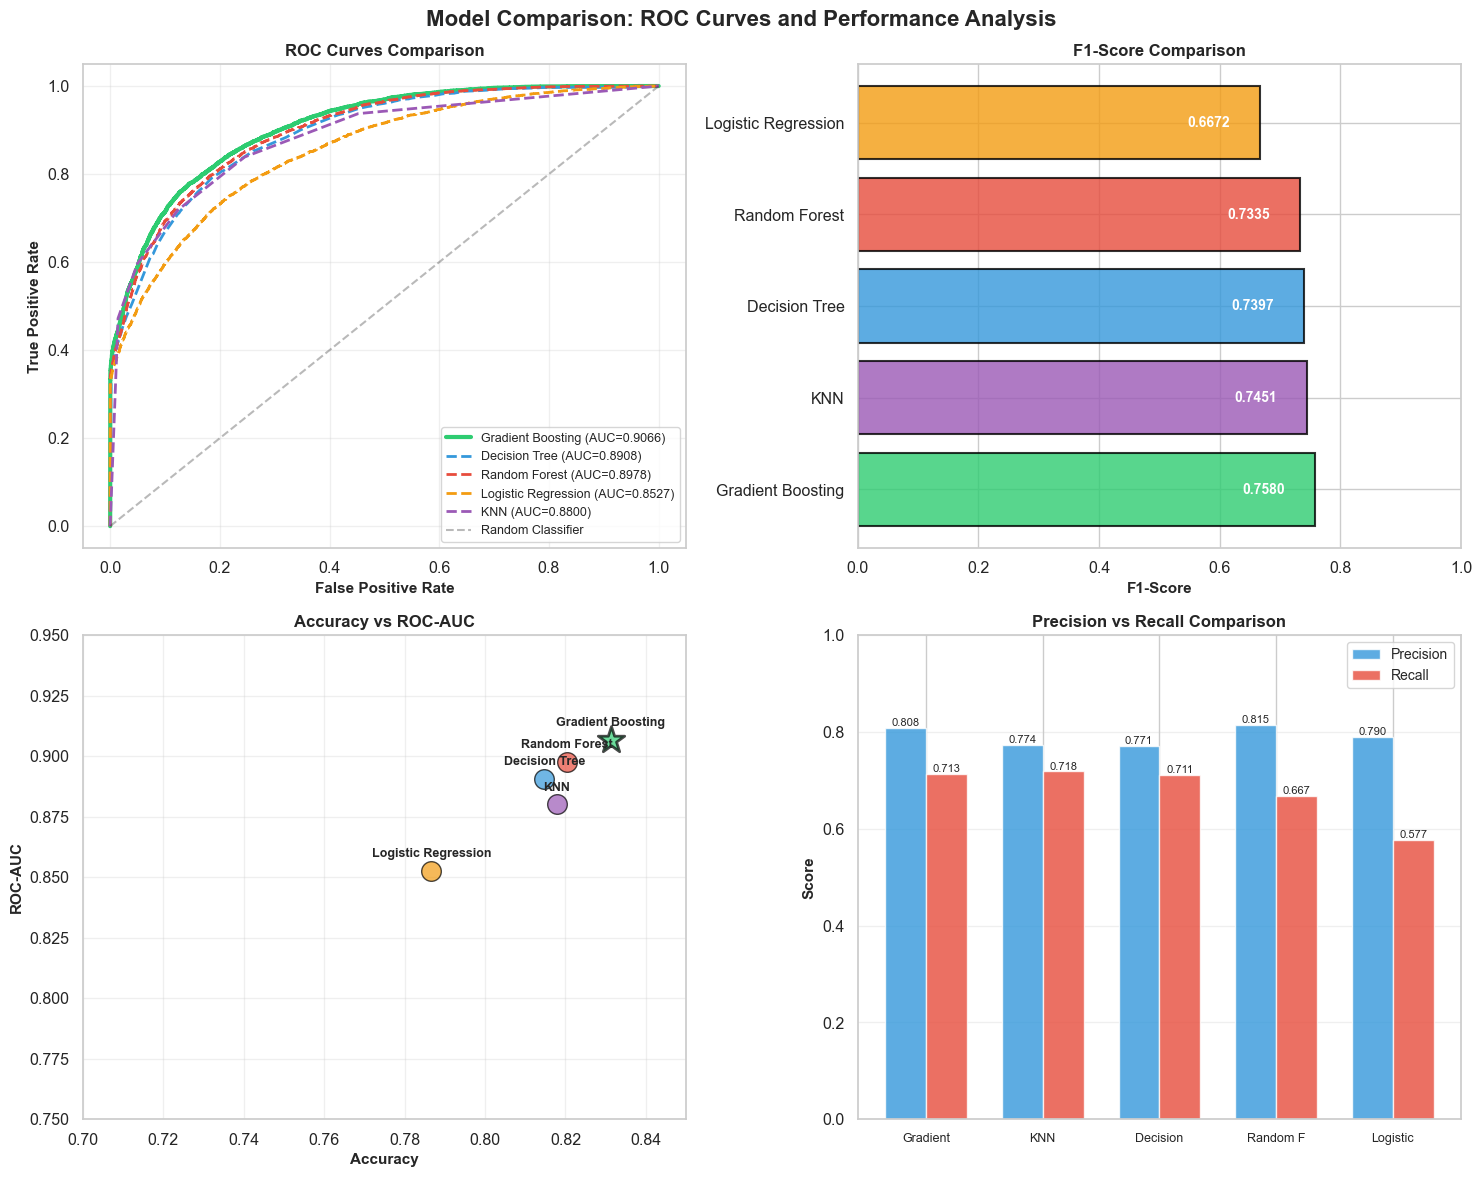

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Comparison: ROC Curves and Performance Analysis', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
for model_name, data in comparison_data.items():
    y_pred_proba = data['y_pred_proba']
    color = data['color']

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    linewidth = 3 if model_name == 'Gradient Boosting' else 2
    linestyle = '-' if model_name == 'Gradient Boosting' else '--'

    ax1.plot(fpr, tpr, label=f'{model_name} (AUC={auc_score:.4f})', 
             color=color, linewidth=linewidth, linestyle=linestyle)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax1.set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(alpha=0.3)

ax2 = axes[0, 1]
models = list(comparison_df.index)
f1_scores = comparison_df['F1-Score'].values
colors_bar = [comparison_data[m]['color'] for m in models]

bars = ax2.barh(models, f1_scores, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax2.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax2.set_xlim([0, 1])

for i, (bar, score) in enumerate(zip(bars, f1_scores)):
    ax2.text(score - 0.05, i, f'{score:.4f}', ha='right', va='center', 
             fontweight='bold', color='white', fontsize=10)

ax3 = axes[1, 0]
for model_name, data in comparison_data.items():
    acc = comparison_metrics[model_name]['Accuracy']
    auc = comparison_metrics[model_name]['ROC-AUC']
    color = data['color']
    size = 400 if model_name == 'Gradient Boosting' else 200
    marker = '*' if model_name == 'Gradient Boosting' else 'o'

    ax3.scatter(acc, auc, s=size, alpha=0.7, color=color, edgecolors='black', 
                linewidth=2 if model_name == 'Gradient Boosting' else 1, marker=marker)
    ax3.annotate(model_name, (acc, auc), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

ax3.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax3.set_ylabel('ROC-AUC', fontsize=11, fontweight='bold')
ax3.set_title('Accuracy vs ROC-AUC', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.set_xlim([0.7, 0.85])
ax3.set_ylim([0.75, 0.95])

ax4 = axes[1, 1]
models = list(comparison_df.index)
precision = comparison_df['Precision'].values
recall = comparison_df['Recall'].values
x_pos = np.arange(len(models))
width = 0.35

bars1 = ax4.bar(x_pos - width/2, precision, width, label='Precision', alpha=0.8, color='#3498db')
bars2 = ax4.bar(x_pos + width/2, recall, width, label='Recall', alpha=0.8, color='#e74c3c')

ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Precision vs Recall Comparison', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([m[:8] for m in models], fontsize=9)
ax4.legend(fontsize=10)
ax4.set_ylim([0, 1])
ax4.grid(alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

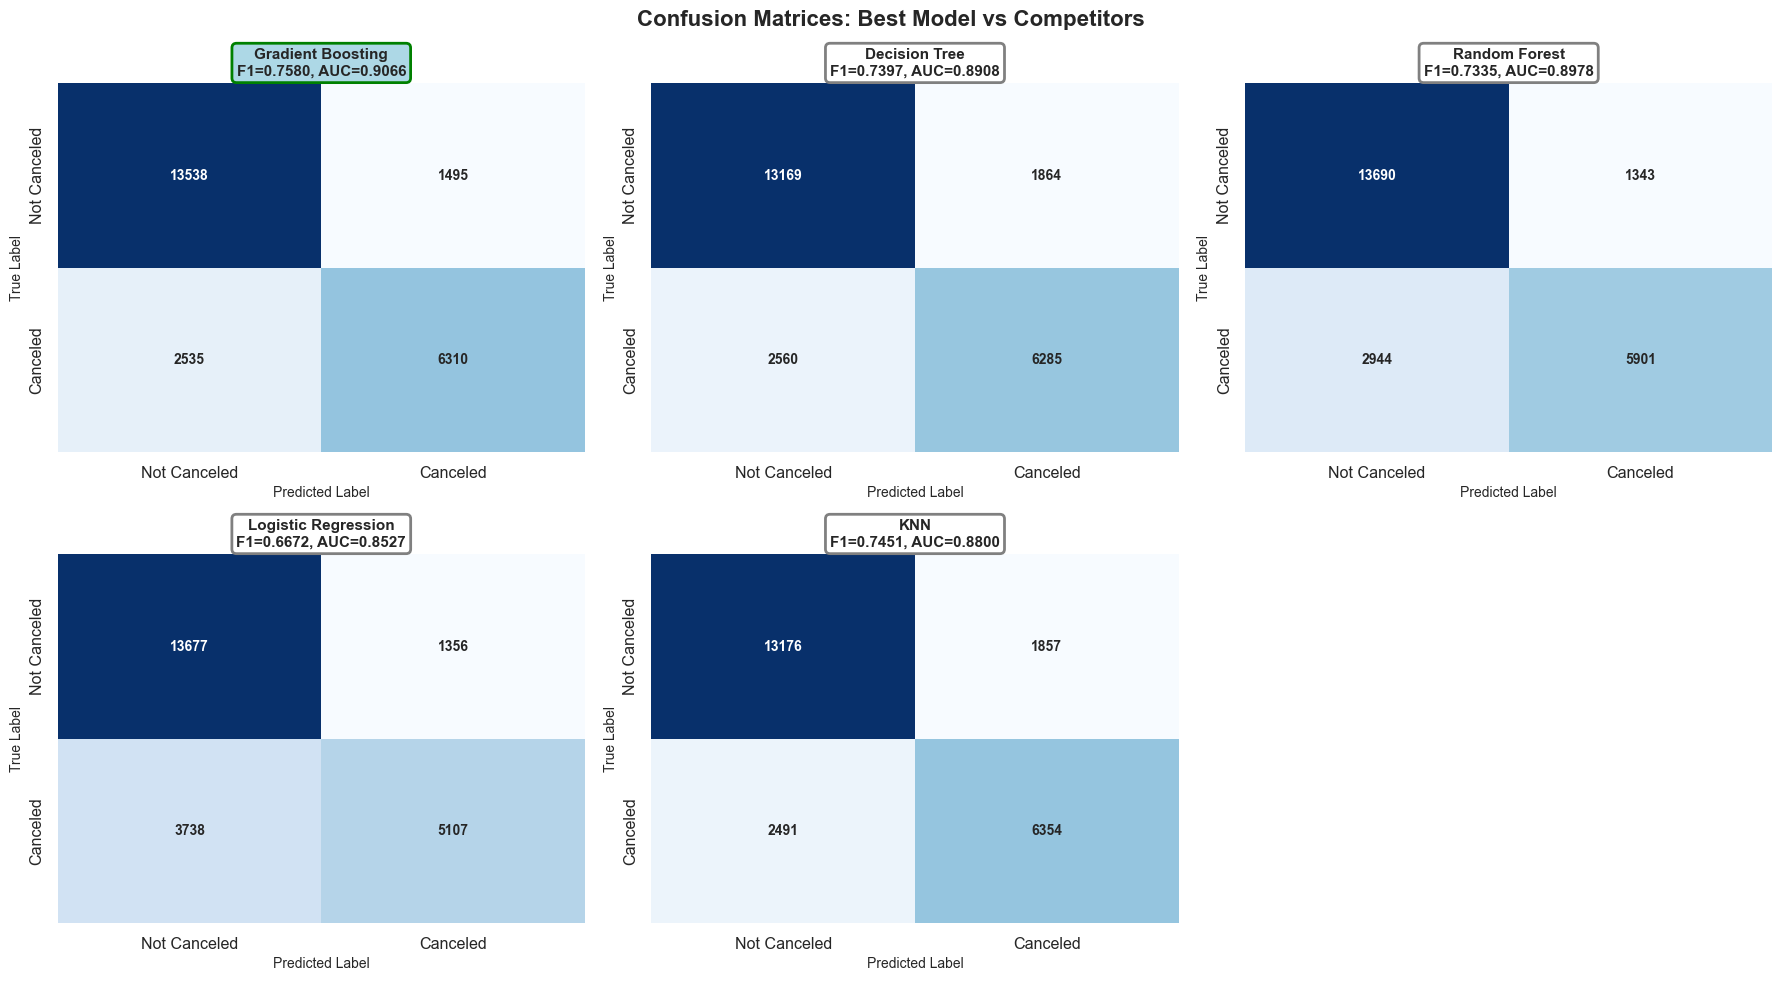

                     True Negatives  False Positives  False Negatives  True Positives  Sensitivity  Specificity       FPR       FNR
Gradient Boosting             13538             1495             2535            6310     0.713397     0.900552  0.099448  0.286603
Decision Tree                 13169             1864             2560            6285     0.710571     0.876006  0.123994  0.289429
Random Forest                 13690             1343             2944            5901     0.667157     0.910663  0.089337  0.332843
Logistic Regression           13677             1356             3738            5107     0.577388     0.909798  0.090202  0.422612
KNN                           13176             1857             2491            6354     0.718372     0.876472  0.123528  0.281628
✓ Best F1-Score    : Gradient Boosting    (0.7580)
✓ Best Accuracy    : Gradient Boosting    (0.8312)
✓ Best ROC-AUC     : Gradient Boosting    (0.9066)
✓ Best Precision   : Random Forest        (0.8146)
✓ Be

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confusion Matrices: Best Model vs Competitors', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, (model_name, data) in enumerate(comparison_data.items()):
    y_pred = data['y_pred']
    cm = confusion_matrix(y_test, y_pred)

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar=False, annot_kws={'fontsize': 10, 'fontweight': 'bold'})

    f1 = comparison_metrics[model_name]['F1-Score']
    auc = comparison_metrics[model_name]['ROC-AUC']
    border_color = 'green' if model_name == 'Gradient Boosting' else 'gray'

    axes[idx].set_title(f'{model_name}\nF1={f1:.4f}, AUC={auc:.4f}', 
                       fontsize=11, fontweight='bold', 
                       bbox=dict(boxstyle='round', facecolor='lightblue' if model_name == 'Gradient Boosting' else 'white', 
                                edgecolor=border_color, linewidth=2))
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].set_xticklabels(['Not Canceled', 'Canceled'])
    axes[idx].set_yticklabels(['Not Canceled', 'Canceled'])

axes[5].axis('off')

plt.tight_layout()
plt.show()

stats_data = {}
for model_name, data in comparison_data.items():
    y_pred = data['y_pred']
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

    stats_data[model_name] = {
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'FPR': false_positive_rate,
        'FNR': false_negative_rate
    }

stats_df = pd.DataFrame(stats_data).T
stats_df = stats_df.astype({'True Negatives': int, 'False Positives': int, 
                             'False Negatives': int, 'True Positives': int})

print(stats_df.to_string())

metrics_to_check = ['F1-Score', 'Accuracy', 'ROC-AUC', 'Precision', 'Recall']
for metric in metrics_to_check:
    best_model = comparison_df[metric].idxmax()
    best_score = comparison_df[metric].max()
    print(f"✓ Best {metric:12s}: {best_model:20s} ({best_score:.4f})")